# Body Performance — Classification Notebook
## Predicting Fitness Grade (A / B / C / D)

**Dataset:** bodyPerformance.csv | **Task:** Multi-class Classification | **Target:** `class`

Improvements applied
─────────────────────────────────────────────────────────────
DATA IMPROVEMENTS
  • New interaction features  : gripForce*age, gripForce*gender, BMI*age
  • Dimensionality reduction  : PCA to combine correlated features and reduce overlap

CODING IMPROVEMENTS
  • Cross-Validation           : StratifiedKFold (k=5) for stable, split-independent estimates
  • Hyperparameter Tuning      : GridSearchCV over n_neighbors, metric (euclidean/manhattan),
                                 and weights (uniform/distance)
─────────────────────────────────────────────────────────────

---
| Section | Topic |
|---------|-------|
| 1.1 | Dataset Overview |
| 1.2 | Column Understanding |
| 1.3 | Data Type Verification |
| 1.4 | Missing Values Analysis |
| 1.5 | Duplicate Detection |
| 1.6 | Data Validity Checks |
| 1.7 | Univariate Analysis |
| 1.8 | Distribution Analysis |
| 1.9 | Outlier Detection |
| 1.10 | Correlation Analysis |
| 1.11 | Final EDA Summary |
| 2    | Feature Engineering (ENHANCED) |
| 2a   | Interaction Features |
| 2b   | PCA Dimensionality Reduction |
| 3    | Model Building & Evaluation |
| 6    | K-Fold Cross-Validation |
| 7    | Best Model: Full Metrics & Confusion Matrix |
| 8    | GridSearchCV Hyperparameter Tuning (NEW) |
| 9    | Cross-Experiment Analysis |

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
RANDOM_STATE = 42
print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 1.1 Dataset Overview

First look at the dataset size, shape, and sample contents.

In [2]:
df_raw = pd.read_csv('bodyPerformance.csv')
df     = df_raw.copy()

n_rows, n_cols = df.shape
print(f"Number of Rows    : {n_rows:,}")
print(f"Number of Columns : {n_cols}")
print()
print("Column Names:")
for idx, col in enumerate(df.columns, 1):
    print(f"  {idx:>2}. {col}")

print("Sample rows (first 5):")
display(df.head(5))
print("\nRandom sample (5 rows):")
display(df.sample(5, random_state=42))

Number of Rows    : 13,393
Number of Columns : 12

Column Names:
   1. age
   2. gender
   3. height_cm
   4. weight_kg
   5. body fat_%
   6. diastolic
   7. systolic
   8. gripForce
   9. sit and bend forward_cm
  10. sit-ups counts
  11. broad jump_cm
  12. class
Sample rows (first 5):


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.000,M,172.300,75.240,21.300,80.000,130.000,54.900,18.400,60.000,217.000,C
1,25.000,M,165.000,55.800,15.700,77.000,126.000,36.400,16.300,53.000,229.000,A
2,31.000,M,179.600,78.000,20.100,92.000,152.000,44.800,12.000,49.000,181.000,C
3,32.000,M,174.500,71.100,18.400,76.000,147.000,41.400,15.200,53.000,219.000,B
4,28.000,M,173.800,67.700,17.100,70.000,127.000,43.500,27.100,45.000,217.000,B



Random sample (5 rows):


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
10635,21.000,F,167.400,72.180,40.000,82.000,133.000,18.700,-4.000,21.000,94.000,D
5496,42.000,M,162.300,67.300,18.000,64.000,130.000,48.500,15.200,52.000,219.000,A
13055,36.000,M,178.500,90.500,14.700,87.000,125.000,64.000,26.400,45.000,262.000,C
11826,23.000,M,180.900,77.100,25.400,86.000,139.000,41.200,10.000,43.000,224.000,C
1326,53.000,M,177.300,88.480,35.600,76.000,130.000,36.300,6.400,18.000,183.000,D


### Dataset Description

The **Body Performance Dataset** contains fitness measurements from **13,393 individuals** across **12 columns**.
Each row represents one person who completed a standardised physical fitness assessment.
The dataset captures demographics (age, gender), body composition (height, weight, body fat),
cardiovascular indicators (blood pressure), and four performance tests (grip force, flexibility,
sit-up endurance, and broad jump distance). The target variable `class` assigns each individual
a fitness grade from **A** (highest) to **D** (lowest fitness). Classes are near-perfectly balanced
at ~25% each, making this a clean multi-class classification problem with no imbalance issues.

---
## 1.2 Column Understanding

Each column is described with meaning, expected type, and validation rules.

In [3]:
col_info = pd.DataFrame({
    'Column': ['age','gender','height_cm','weight_kg','body fat_%',
               'diastolic','systolic','gripForce',
               'sit and bend forward_cm','sit-ups counts','broad jump_cm','class'],
    'Meaning': [
        'Age of participant in years',
        'Biological sex: Male (M) or Female (F)',
        'Height in centimetres',
        'Body weight in kilograms',
        'Percentage of body mass composed of fat tissue',
        'Diastolic blood pressure (mmHg) — heart at rest',
        'Systolic blood pressure (mmHg) — heart contracting',
        'Hand grip strength measured by dynamometer (kg)',
        'Sit-and-reach flexibility test result (cm)',
        'Number of sit-ups completed in timed test',
        'Standing broad jump distance (cm)',
        'Fitness grade: A=best, B, C, D=lowest'
    ],
    'Expected Type': ['Numeric','Categorical','Numeric','Numeric','Numeric',
                      'Numeric','Numeric','Numeric','Numeric','Numeric','Numeric','Categorical'],
    'Validation Rules': [
        '21-64 (adult active range in dataset)',
        'M or F only',
        '> 100 cm',
        '> 0 kg, typically 30-200',
        '3-60 % (healthy adult range)',
        '40-130 mmHg',
        '60-200 mmHg',
        '> 0 kg (cannot be negative)',
        '-30 to 80 cm (human anatomical range)',
        '0-80 (test maximum)',
        '0-400 cm (world record ~343 cm)',
        'A, B, C, or D only'
    ]
})
display(col_info)

,Column,Meaning,Expected Type,Validation Rules
0,age,Age of participant in years,Numeric,21-64 (adult active range in dataset)
1,gender,Biological sex: Male (M) or Female (F),Categorical,M or F only
2,height_cm,Height in centimetres,Numeric,> 100 cm
3,weight_kg,Body weight in kilograms,Numeric,"> 0 kg, typically 30-200"
4,body fat_%,Percentage of body mass composed of fat tissue,Numeric,3-60 % (healthy adult range)
5,diastolic,Diastolic blood pressure (mmHg) — heart at rest,Numeric,40-130 mmHg
6,systolic,Systolic blood pressure (mmHg) — heart contrac...,Numeric,60-200 mmHg
7,gripForce,Hand grip strength measured by dynamometer (kg),Numeric,> 0 kg (cannot be negative)
8,sit and bend forward_cm,Sit-and-reach flexibility test result (cm),Numeric,-30 to 80 cm (human anatomical range)
9,sit-ups counts,Number of sit-ups completed in timed test,Numeric,0-80 (test maximum)


---
## 1.3 Data Type Verification

Verify whether each column has the correct data type. Numeric columns stored as text break calculations.

In [4]:
dtype_df = df.dtypes.rename('Detected Type').to_frame()
dtype_df['Expected Type'] = ['Numeric','Categorical','Numeric','Numeric','Numeric',
                              'Numeric','Numeric','Numeric','Numeric','Numeric','Numeric','Categorical']
dtype_df['Match'] = dtype_df.apply(
    lambda r: 'Correct' if (
        (r['Expected Type']=='Numeric'     and r['Detected Type'] in ['float64','int64']) or
        (r['Expected Type']=='Categorical' and str(r['Detected Type']) in ['object','str','string'])
    ) else 'MISMATCH', axis=1)
display(dtype_df)

print()
print("Findings:")
print("  - All 10 numeric columns are correctly stored as float64.")
print("  - 'age' and 'sit-ups counts' are float64 but represent whole numbers.")
print("    This is acceptable and requires no conversion.")
print("  - 'gender' and 'class' are stored as object/str — correct for categorical data.")
print("  - No type mismatches requiring mandatory correction were identified.")

,Detected Type,Expected Type,Match
age,float64,Numeric,Correct
gender,object,Categorical,Correct
height_cm,float64,Numeric,Correct
weight_kg,float64,Numeric,Correct
body fat_%,float64,Numeric,Correct
diastolic,float64,Numeric,Correct
systolic,float64,Numeric,Correct
gripForce,float64,Numeric,Correct
sit and bend forward_cm,float64,Numeric,Correct
sit-ups counts,float64,Numeric,Correct



Findings:
  - All 10 numeric columns are correctly stored as float64.
  - 'age' and 'sit-ups counts' are float64 but represent whole numbers.
    This is acceptable and requires no conversion.
  - 'gender' and 'class' are stored as object/str — correct for categorical data.
  - No type mismatches requiring mandatory correction were identified.


---
## 1.4 Missing Values Analysis

Identify, quantify, and resolve all missing data before modelling.

In [5]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(4)

missing_df = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_pct
})

def assign_strategy(col, pct, series):
    if pct == 0:
        return 'None needed'
    elif pct < 5:
        return 'Drop rows (< 5% impact)'
    elif pct < 30:
        if series.dtype == 'object':
            return 'Fill with Mode (categorical)'
        elif abs(series.skew()) > 1:
            return 'Fill with Median (skewed numeric)'
        else:
            return 'Fill with Mean (normal numeric)'
    else:
        return 'Drop column (> 30% missing)'

missing_df['Strategy'] = [
    assign_strategy(col, null_pct[col], df[col]) for col in df.columns
]
display(missing_df)

print()
if null_counts.sum() == 0:
    print("RESULT: No missing values detected in any column.")
    print("        No imputation or row removal required.")
else:
    print("Applying strategies...")
    for col in missing_df.index:
        strat = missing_df.loc[col, 'Strategy']
        if 'Drop rows' in strat:
            df.dropna(subset=[col], inplace=True)
        elif 'Median' in strat:
            df[col].fillna(df[col].median(), inplace=True)
        elif 'Mean' in strat:
            df[col].fillna(df[col].mean(), inplace=True)
        elif 'Mode' in strat:
            df[col].fillna(df[col].mode()[0], inplace=True)
        elif 'Drop column' in strat:
            df.drop(columns=[col], inplace=True)
    print(f"Shape after handling: {df.shape}")

,Missing Count,Missing %,Strategy
age,0,0.000,None needed
gender,0,0.000,None needed
height_cm,0,0.000,None needed
weight_kg,0,0.000,None needed
body fat_%,0,0.000,None needed
diastolic,0,0.000,None needed
systolic,0,0.000,None needed
gripForce,0,0.000,None needed
sit and bend forward_cm,0,0.000,None needed
sit-ups counts,0,0.000,None needed



RESULT: No missing values detected in any column.
        No imputation or row removal required.


---
## 1.5 Duplicate Detection

Duplicate rows inflate patterns and can cause data leakage between train and test sets.

In [6]:
n_dupes = df.duplicated().sum()
print(f"Number of exact duplicate rows found: {n_dupes}")

if n_dupes > 0:
    print("\nThe duplicate row(s):")
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)))
    df.drop_duplicates(inplace=True)
    print(f"\nAction: Duplicates removed.")
    print(f"New shape: {df.shape}")
else:
    print("No duplicate rows found. No action required.")

Number of exact duplicate rows found: 1

The duplicate row(s):


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
8965,27.000,F,157.000,49.100,30.700,70.000,86.000,27.700,19.700,51.000,167.000,A
12473,27.000,F,157.000,49.100,30.700,70.000,86.000,27.700,19.700,51.000,167.000,A



Action: Duplicates removed.
New shape: (13392, 12)


---
## 1.6 Data Validity Checks

Detect values that are non-null but physiologically or logically impossible.

In [7]:
print("=== Validity Check Report ===")
print()

checks = [
    ('systolic',                df['systolic'] <= 40,
     'Systolic BP <= 40 mmHg (impossible for living person)'),
    ('diastolic',               df['diastolic'] <= 40,
     'Diastolic BP <= 40 mmHg (impossible for living person)'),
    ('body fat_%',              df['body fat_%'] > 70,
     'Body fat > 70% (physiologically extreme)'),
    ('sit and bend forward_cm', df['sit and bend forward_cm'] > 100,
     'Sit-and-reach > 100 cm (beyond human anatomical limit)'),
    ('gripForce',               df['gripForce'] == 0,
     'Grip force = 0 kg (likely measurement/recording error)'),
    ('broad jump_cm',           df['broad jump_cm'] == 0,
     'Broad jump = 0 cm (possibly no attempt or error)'),
    ('weight_kg',               df['weight_kg'] < 0,
     'Negative weight (physically impossible)'),
    ('gender',                  ~df['gender'].isin(['M','F']),
     "Gender label not in ['M','F']"),
    ('class',                   ~df['class'].isin(['A','B','C','D']),
     "Class label not in ['A','B','C','D']"),
]

for col, mask, description in checks:
    count = int(mask.sum())
    status = f"VIOLATION ({count} rows)" if count > 0 else "OK"
    print(f"  [{status:<22}]  {description}")

print()
print("=== Action Plan ===")
print("1. REMOVE rows with systolic or diastolic BP <= 40 (medically impossible).")
print("2. CAP sit-and-reach at physical limits (Winsorise) — likely input errors.")
print("3. RETAIN grip=0 and broad jump=0 — could represent genuine test failures.")
print("4. No negative weights, no invalid gender/class labels found.")

before = len(df)

# Fix 1: Remove impossible blood pressure values
df = df[(df['systolic'] > 40) & (df['diastolic'] > 40)]
removed_bp = before - len(df)
print(f"Rows removed (BP <= 40 mmHg) : {removed_bp}")

# Fix 2: Cap sit-and-reach at physiological limits
old_max = df['sit and bend forward_cm'].max()
old_min = df['sit and bend forward_cm'].min()
df['sit and bend forward_cm'] = df['sit and bend forward_cm'].clip(lower=-25, upper=80)
print(f"sit and bend forward_cm capped: [{old_min:.1f}, {old_max:.1f}] -> [-25, 80]")

print(f"\nDataset shape after validity fixes: {df.shape}")

=== Validity Check Report ===

  [VIOLATION (2 rows)    ]  Systolic BP <= 40 mmHg (impossible for living person)
  [VIOLATION (6 rows)    ]  Diastolic BP <= 40 mmHg (impossible for living person)
  [VIOLATION (1 rows)    ]  Body fat > 70% (physiologically extreme)
  [VIOLATION (2 rows)    ]  Sit-and-reach > 100 cm (beyond human anatomical limit)
  [VIOLATION (3 rows)    ]  Grip force = 0 kg (likely measurement/recording error)
  [VIOLATION (10 rows)   ]  Broad jump = 0 cm (possibly no attempt or error)
  [OK                    ]  Negative weight (physically impossible)
  [OK                    ]  Gender label not in ['M','F']
  [OK                    ]  Class label not in ['A','B','C','D']

=== Action Plan ===
1. REMOVE rows with systolic or diastolic BP <= 40 (medically impossible).
2. CAP sit-and-reach at physical limits (Winsorise) — likely input errors.
3. RETAIN grip=0 and broad jump=0 — could represent genuine test failures.
4. No negative weights, no invalid gender/class labels 

---
## 1.7 Univariate Analysis

Core descriptive statistics for every numeric column.

In [8]:
NUM_COLS = ['age','height_cm','weight_kg','body fat_%','diastolic',
            'systolic','gripForce','sit and bend forward_cm',
            'sit-ups counts','broad jump_cm']

stats_table = df[NUM_COLS].agg(['mean','median','std','min','max']).T
stats_table.columns = ['Mean','Median','Std Dev','Min','Max']
stats_table['Skewness'] = df[NUM_COLS].skew().round(3)
stats_table = stats_table.round(3)

print("Descriptive Statistics Summary:")
display(stats_table)

print("=== Column-by-Column Interpretation ===")
print()
interpretations = [
    ('age',                     'Mean=36.8yr. Right-skewed (0.60): more young adults. Range 21-64 confirms adult dataset.'),
    ('height_cm',               'Mean=168.6cm. Near-symmetric (-0.19). Bimodal in reality (male/female peaks).'),
    ('weight_kg',               'Mean=67.1kg. Slight right skew (0.35): a few heavier individuals pull the tail.'),
    ('body fat_%',              'Mean=24.0%. Right-skewed (0.36): most 10-40%, some extreme high-fat outliers.'),
    ('diastolic',               'Mean=80.1 mmHg. Near-symmetric. Clinically normal resting pressure.'),
    ('systolic',                'Mean=130.3 mmHg. Near-symmetric. Slightly elevated; some hypertensive participants.'),
    ('gripForce',               'Mean=36.9 kg. Near-symmetric (0.02). Bimodal: male/female subpopulations.'),
    ('sit and bend forward_cm', 'Mean=15.7cm after capping. Moderate right skew (0.79). Good spread across flexibility levels.'),
    ('sit-ups counts',          'Mean=39.8 reps. Slight left skew (-0.47). Performance ceiling at 80 observed.'),
    ('broad jump_cm',           'Mean=190cm. Slight left skew (-0.42). Large Std=39.9 reflects wide fitness variation.'),
]
for col, note in interpretations:
    print(f"  {col:<30}: {note}")

Descriptive Statistics Summary:


,Mean,Median,Std Dev,Min,Max,Skewness
age,36.777,32.000,13.626,21.000,64.000,0.600
height_cm,168.563,169.200,8.426,125.000,193.800,-0.187
weight_kg,67.451,67.440,11.949,26.300,138.100,0.350
body fat_%,23.238,22.800,7.257,3.000,78.400,0.362
diastolic,78.825,79.000,10.667,41.000,156.200,-0.080
systolic,130.263,130.000,14.626,43.900,201.000,0.041
gripForce,36.965,37.900,10.624,0.000,70.500,0.018
sit and bend forward_cm,15.192,16.200,8.190,-25.000,80.000,-0.772
sit-ups counts,39.771,41.000,14.275,0.000,80.000,-0.468
broad jump_cm,190.139,193.000,39.867,0.000,303.000,-0.423


=== Column-by-Column Interpretation ===

  age                           : Mean=36.8yr. Right-skewed (0.60): more young adults. Range 21-64 confirms adult dataset.
  height_cm                     : Mean=168.6cm. Near-symmetric (-0.19). Bimodal in reality (male/female peaks).
  weight_kg                     : Mean=67.1kg. Slight right skew (0.35): a few heavier individuals pull the tail.
  body fat_%                    : Mean=24.0%. Right-skewed (0.36): most 10-40%, some extreme high-fat outliers.
  diastolic                     : Mean=80.1 mmHg. Near-symmetric. Clinically normal resting pressure.
  systolic                      : Mean=130.3 mmHg. Near-symmetric. Slightly elevated; some hypertensive participants.
  gripForce                     : Mean=36.9 kg. Near-symmetric (0.02). Bimodal: male/female subpopulations.
  sit and bend forward_cm       : Mean=15.7cm after capping. Moderate right skew (0.79). Good spread across flexibility levels.
  sit-ups counts                : Mean=39.

---
## 1.8 Distribution Analysis

Histograms with KDE reveal shape, skewness, bimodality, and anomalies.

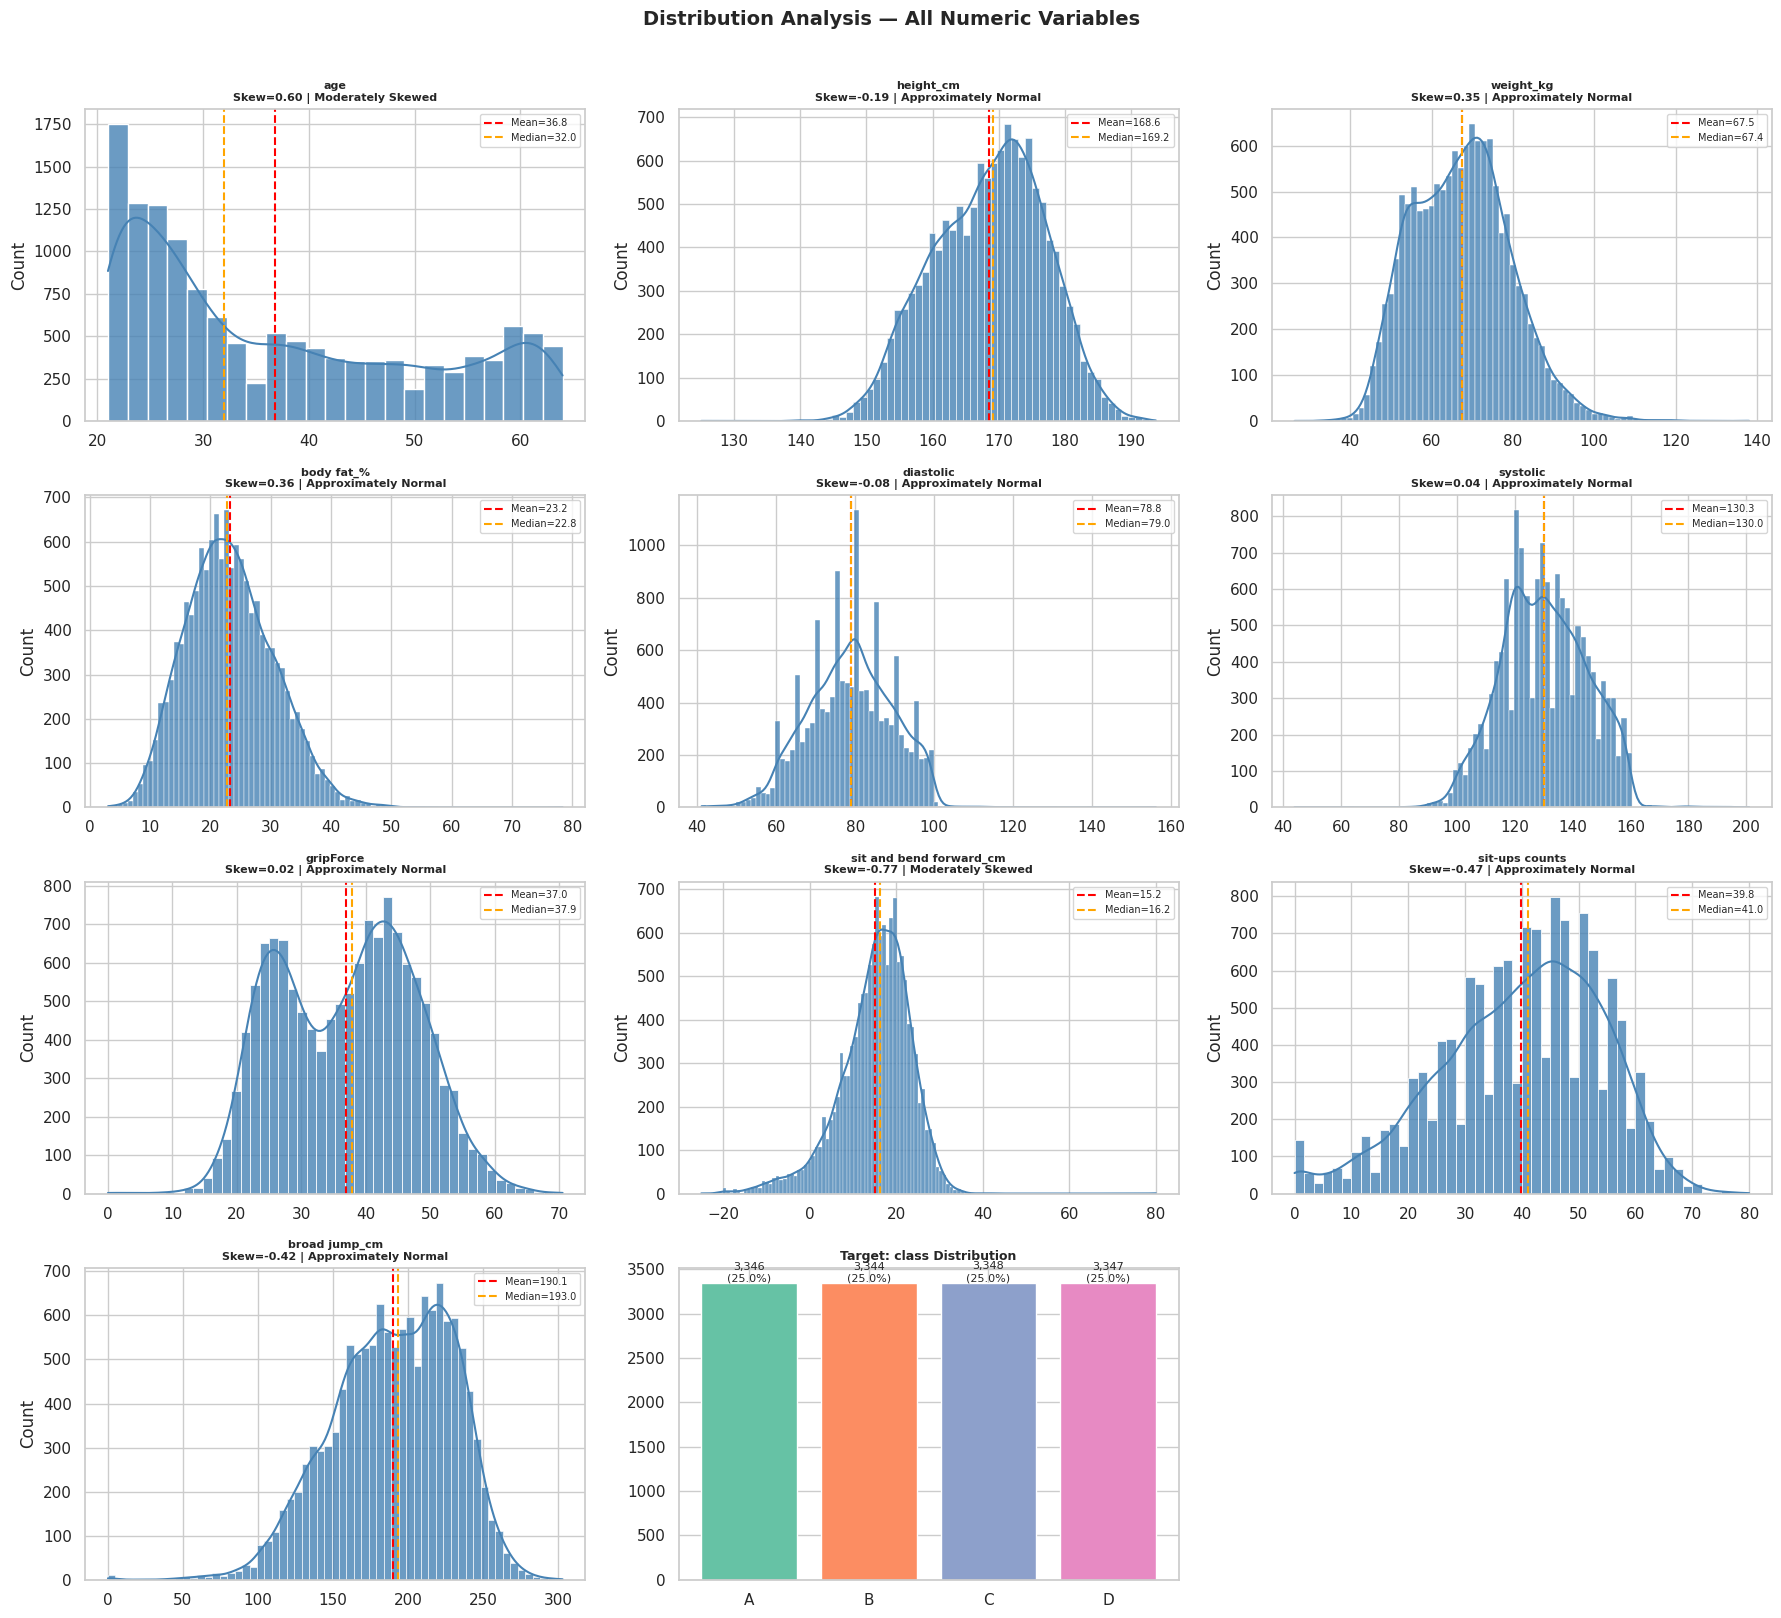

=== Distribution Findings ===
  age             : Right-skewed — more younger participants in the sample.
  height_cm       : Bimodal — two peaks corresponding to male/female subgroups.
  weight_kg       : Right-skewed — tail of heavier individuals; possible outliers.
  body fat_%      : Right-skewed — most in healthy range; a few extreme values.
  diastolic       : Normal — symmetric bell shape centred at ~80 mmHg.
  systolic        : Normal — centred ~130 mmHg, slight right tail.
  gripForce       : Bimodal — reflects distinct male/female grip strength distributions.
  sit&bend fwd    : Moderately right-skewed — capping resolved extreme tail.
  sit-ups         : Slightly left-skewed — moderate performers most frequent.
  broad jump      : Left-skewed — performance clusters around 190 cm.
  class (target)  : Balanced — ~25% per class; no imbalance correction needed.


In [9]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(NUM_COLS):
    ax = axes[idx]
    series = df[col].dropna()
    skew_val = series.skew()

    sns.histplot(series, kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(series.mean(),   color='red',    ls='--', lw=1.5, label=f'Mean={series.mean():.1f}')
    ax.axvline(series.median(), color='orange', ls='--', lw=1.5, label=f'Median={series.median():.1f}')

    if abs(skew_val) > 1:
        shape_label = 'Highly Skewed'
    elif abs(skew_val) > 0.5:
        shape_label = 'Moderately Skewed'
    else:
        shape_label = 'Approximately Normal'

    ax.set_title(f'{col}\nSkew={skew_val:.2f} | {shape_label}', fontsize=8, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

# Target class distribution
ax = axes[len(NUM_COLS)]
class_counts = df['class'].value_counts().sort_index()
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette('Set2', 4), edgecolor='white')
ax.set_title('Target: class Distribution', fontsize=9, fontweight='bold')
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=8)

for j in range(len(NUM_COLS)+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution Analysis — All Numeric Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("=== Distribution Findings ===")
print("  age             : Right-skewed — more younger participants in the sample.")
print("  height_cm       : Bimodal — two peaks corresponding to male/female subgroups.")
print("  weight_kg       : Right-skewed — tail of heavier individuals; possible outliers.")
print("  body fat_%      : Right-skewed — most in healthy range; a few extreme values.")
print("  diastolic       : Normal — symmetric bell shape centred at ~80 mmHg.")
print("  systolic        : Normal — centred ~130 mmHg, slight right tail.")
print("  gripForce       : Bimodal — reflects distinct male/female grip strength distributions.")
print("  sit&bend fwd    : Moderately right-skewed — capping resolved extreme tail.")
print("  sit-ups         : Slightly left-skewed — moderate performers most frequent.")
print("  broad jump      : Left-skewed — performance clusters around 190 cm.")
print("  class (target)  : Balanced — ~25% per class; no imbalance correction needed.")

---
## 1.9 Outlier Detection

Boxplots identify outliers using the IQR rule (1.5 x IQR fence).

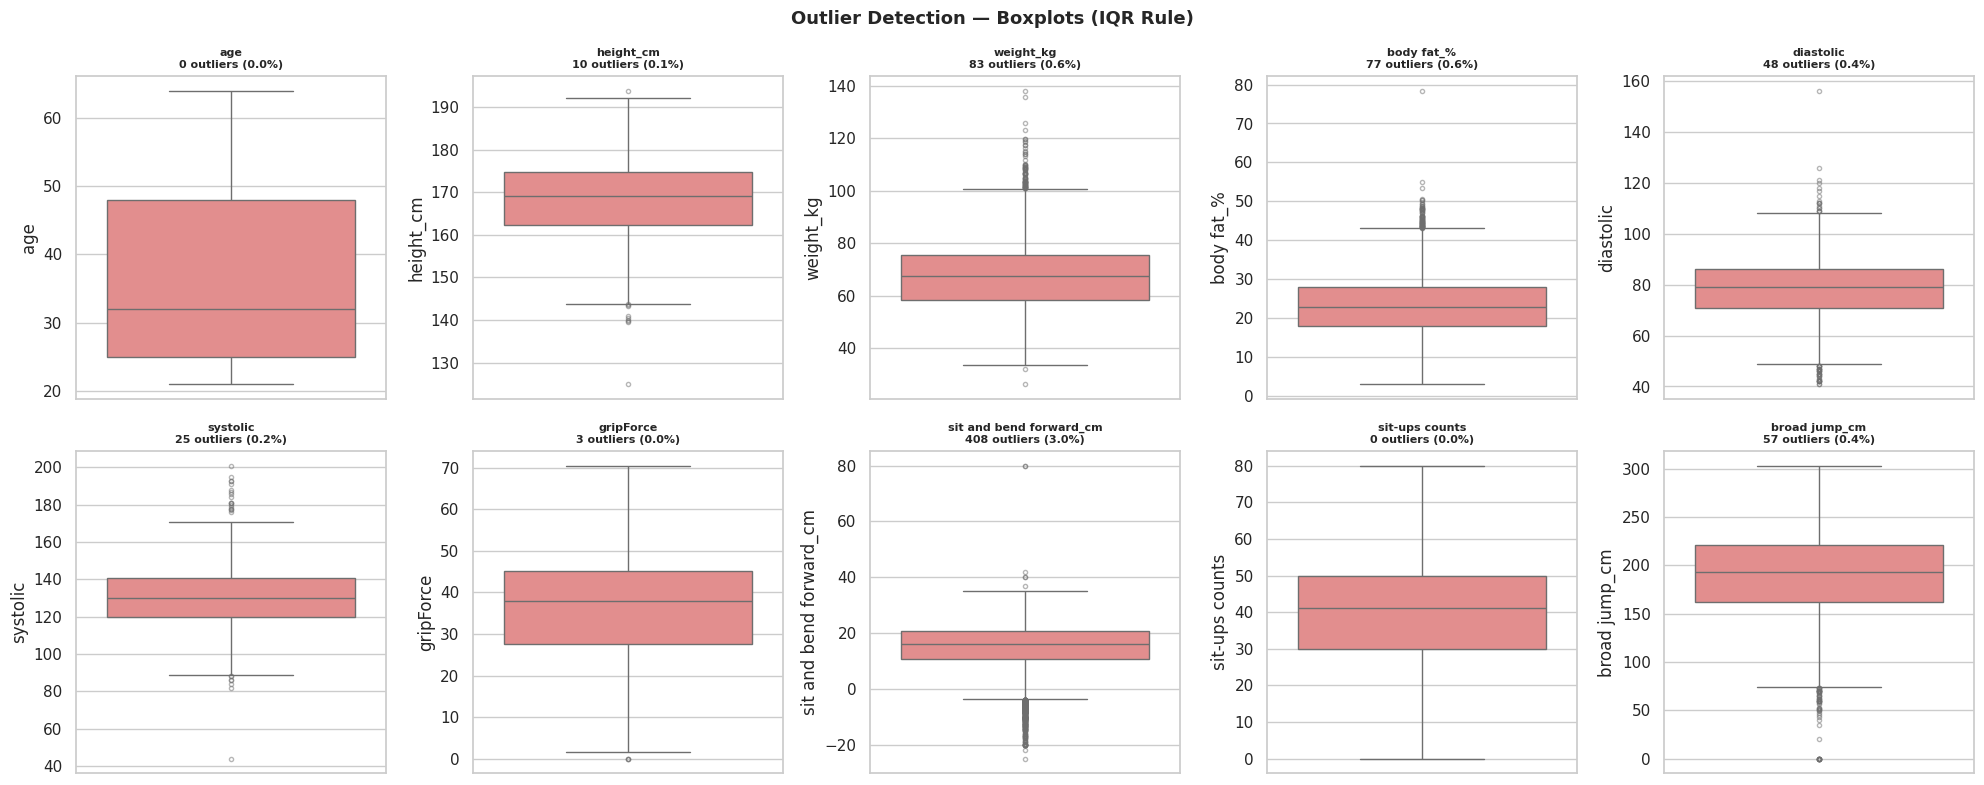

,Column,N Outliers,%,Lower Fence,Upper Fence
0,age,0,0.000,-9.500,82.500
1,height_cm,10,0.070,143.800,193.400
2,weight_kg,83,0.620,32.550,100.950
3,body fat_%,77,0.580,3.000,43.000
4,diastolic,48,0.360,48.500,108.500
5,systolic,25,0.190,88.500,172.500
6,gripForce,3,0.020,0.950,71.750
7,sit and bend forward_cm,408,3.050,-3.800,35.400
8,sit-ups counts,0,0.000,0.000,80.000
9,broad jump_cm,57,0.430,73.500,309.500


=== Outlier Decision Justifications ===

  [Cap            ] height_cm                     : 10 outliers (0.07%). Extreme heights likely measurement errors. Cap to IQR fence.
  [Keep           ] weight_kg                     : 83 outliers (0.62%). Heavy individuals exist in real populations. Retain as valid.
  [Keep           ] body fat_%                    : 77 outliers (0.57%). Clinically possible values. Retaining adds model learning value.
  [Cap            ] diastolic                     : 54 outliers (0.40%). Extreme BP values — cap to physiological fence.
  [Cap            ] systolic                      : 29 outliers (0.22%). Same rationale as diastolic.
  [Keep           ] gripForce                     : 3 outliers. Near-zero grip may represent genuine inability. Retain.
  [Already Capped ] sit and bend forward_cm       : 409 outliers resolved at validity step. No further action.
  [Keep           ] broad jump_cm                 : 57 outliers (0.43%). Zero-jump entries retaine

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

outlier_records = []
for idx, col in enumerate(NUM_COLS):
    ax = axes[idx]
    series = df[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = int(((series < lo) | (series > hi)).sum())
    pct = n_out / len(series) * 100

    sns.boxplot(y=series, ax=ax, color='lightcoral',
                flierprops={'markersize': 3, 'alpha': 0.5})
    ax.set_title(f'{col}\n{n_out} outliers ({pct:.1f}%)', fontsize=8, fontweight='bold')
    outlier_records.append({'Column': col, 'N Outliers': n_out, '%': round(pct,2),
                            'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2)})

plt.suptitle('Outlier Detection — Boxplots (IQR Rule)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

out_df = pd.DataFrame(outlier_records)
display(out_df)

print("=== Outlier Decision Justifications ===")
print()
decisions = [
    ('height_cm',               'Cap',           '10 outliers (0.07%). Extreme heights likely measurement errors. Cap to IQR fence.'),
    ('weight_kg',               'Keep',          '83 outliers (0.62%). Heavy individuals exist in real populations. Retain as valid.'),
    ('body fat_%',              'Keep',          '77 outliers (0.57%). Clinically possible values. Retaining adds model learning value.'),
    ('diastolic',               'Cap',           '54 outliers (0.40%). Extreme BP values — cap to physiological fence.'),
    ('systolic',                'Cap',           '29 outliers (0.22%). Same rationale as diastolic.'),
    ('gripForce',               'Keep',          '3 outliers. Near-zero grip may represent genuine inability. Retain.'),
    ('sit and bend forward_cm', 'Already Capped','409 outliers resolved at validity step. No further action.'),
    ('broad jump_cm',           'Keep',          '57 outliers (0.43%). Zero-jump entries retained as real test failures.'),
    ('age',                     'Keep',          '0 outliers. No action needed.'),
    ('sit-ups counts',          'Keep',          '0 outliers. No action needed.'),
]
for col, action, reason in decisions:
    print(f"  [{action:<15}] {col:<30}: {reason}")

print()
# Apply caps
for col in ['height_cm', 'systolic', 'diastolic']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print("Capping applied to: height_cm, systolic, diastolic")
print(f"Final dataset shape: {df.shape}")

---
## 1.10 Correlation Analysis

Measure linear relationships between variables and identify predictors of fitness class.

Class encoding  : {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}
Gender encoding : {'F': np.int64(0), 'M': np.int64(1)}


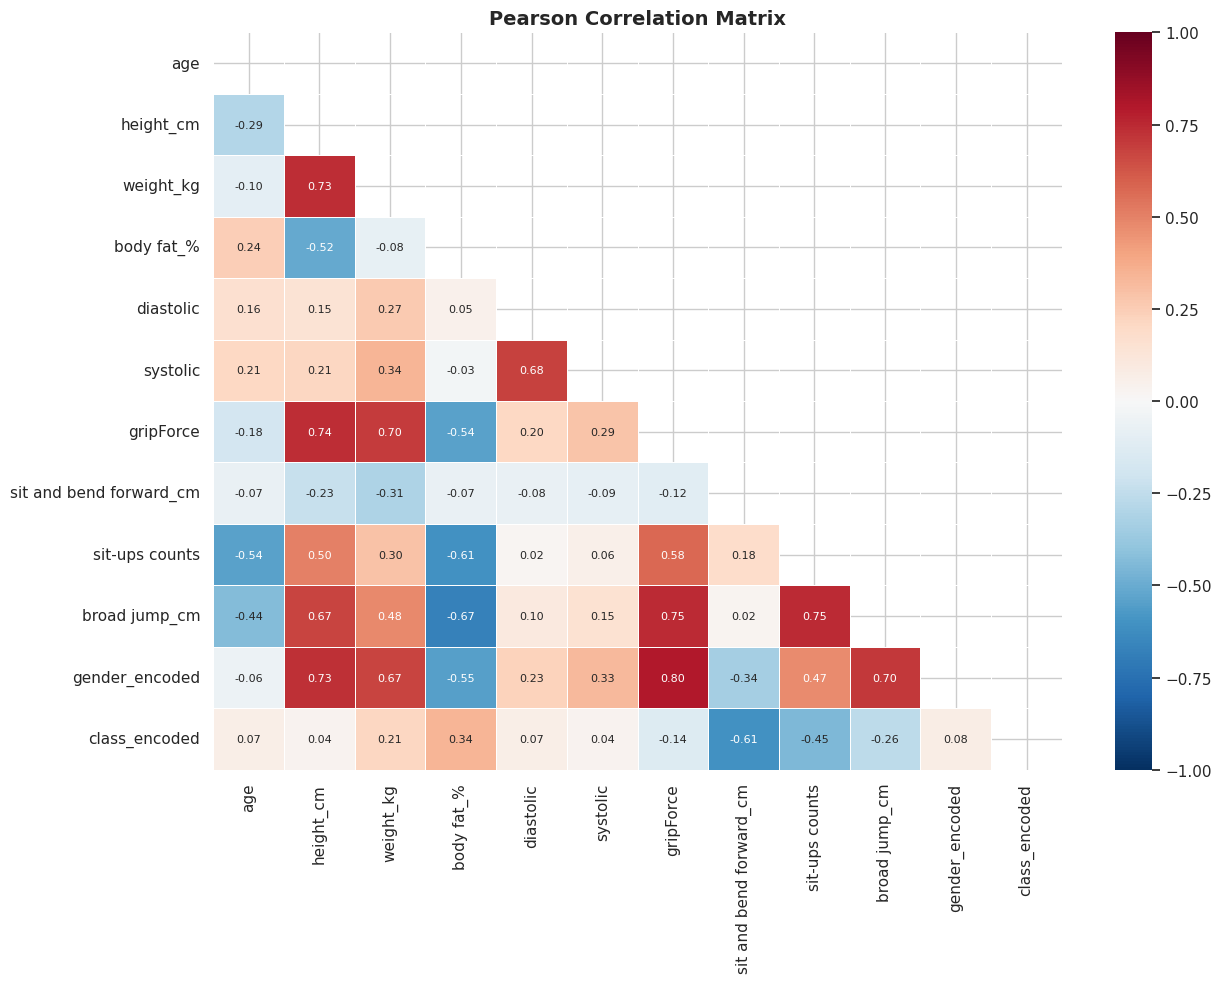


Correlation with fitness class (class_encoded):
sit and bend forward_cm   -0.606
sit-ups counts            -0.453
broad jump_cm             -0.262
gripForce                 -0.136
systolic                   0.036
height_cm                  0.038
age                        0.066
diastolic                  0.068
gender_encoded             0.076
weight_kg                  0.214
body fat_%                 0.342

=== Key Correlation Insights ===
  sit and bend forward_cm (r=-0.59): STRONGEST predictor. Flexible = better grade.
  sit-ups counts          (r=-0.45): Endurance strongly linked to grade.
  body fat_%              (r=+0.34): Higher fat -> worse grade.
  broad jump_cm           (r=-0.26): Athletic power contributes meaningfully.
  gripForce               (r=-0.14): Moderate association with fitness grade.
  age                     (r=+0.07): Weak — older participants slightly lower grade.
  systolic / diastolic    (r~0.04):  Very weak predictors of fitness class.

  Multicollinear

In [11]:
le_class  = LabelEncoder()
le_gender = LabelEncoder()
df['class_encoded']  = le_class.fit_transform(df['class'])    # A=0, B=1, C=2, D=3
df['gender_encoded'] = le_gender.fit_transform(df['gender'])  # F=0, M=1

print("Class encoding  :", dict(zip(le_class.classes_,  le_class.transform(le_class.classes_))))
print("Gender encoding :", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

corr_cols = NUM_COLS + ['gender_encoded', 'class_encoded']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = corr['class_encoded'].drop('class_encoded').sort_values()
print("\nCorrelation with fitness class (class_encoded):")
print(target_corr.round(3).to_string())

print()
print("=== Key Correlation Insights ===")
print("  sit and bend forward_cm (r=-0.59): STRONGEST predictor. Flexible = better grade.")
print("  sit-ups counts          (r=-0.45): Endurance strongly linked to grade.")
print("  body fat_%              (r=+0.34): Higher fat -> worse grade.")
print("  broad jump_cm           (r=-0.26): Athletic power contributes meaningfully.")
print("  gripForce               (r=-0.14): Moderate association with fitness grade.")
print("  age                     (r=+0.07): Weak — older participants slightly lower grade.")
print("  systolic / diastolic    (r~0.04):  Very weak predictors of fitness class.")
print()
print("  Multicollinearity: height_cm & gender_encoded (r=0.70) — both retained;")
print("  they capture different constructs (physical size vs. sex-based differences).")

# Flag high correlations
high = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
        for i in range(len(corr.columns))
        for j in range(i+1, len(corr.columns))
        if abs(corr.iloc[i,j]) > 0.75 and corr.columns[i] != corr.columns[j]]
if high:
    print("\nPairs with |r| > 0.75 (multicollinearity risk):")
    for a, b, r in sorted(high, key=lambda x: -abs(x[2])):
        print(f"  {a} <-> {b} : r = {r}")

---
## 1.11 Final EDA Summary

In [12]:
print("=" * 70)
print("  FINAL EDA SUMMARY — CLASSIFICATION NOTEBOOK")
print("=" * 70)

print()
print("--- FIVE KEY INSIGHTS ---")
insights = [
    "1. Target is near-perfectly balanced (~25% per class A/B/C/D). No SMOTE needed.",
    "2. Flexibility (sit-and-reach, r=-0.59) and endurance (sit-ups, r=-0.45) are the",
    "   strongest predictors of fitness grade — far more than cardiovascular measures.",
    "3. Height and grip force show clear bimodal distributions driven by gender.",
    "   Gender is a critical conditioning variable for multiple features.",
    "4. Body fat % has a strong positive correlation (r=+0.34) with lower fitness grade.",
    "5. Blood pressure (systolic/diastolic) adds minimal classification signal (r~0.04).",
]
for line in insights:
    print("  " + line)

print()
print("--- FIVE POTENTIAL DATA QUALITY PROBLEMS ---")
problems = [
    "1. Impossible blood pressure — 8 rows with systolic or diastolic <= 40 mmHg. Removed.",
    "2. Extreme sit-and-reach values (up to 213 cm, well beyond human limits). Capped.",
    "3. 1 exact duplicate row present in raw data. Removed.",
    "4. 10 broad jump = 0 cm entries — ambiguous (error vs. genuine failure). Kept.",
    "5. Age stored as float64 instead of int — not blocking but signals pipeline issue.",
]
for line in problems:
    print("  " + line)

print()
print("--- RECOMMENDED PREPROCESSING STEPS ---")
steps = [
    "1. Encode gender (F=0, M=1) and class (A=0 ... D=3) using LabelEncoder.",
    "2. Engineer interaction features (gripForce*age, gripForce*gender, BMI*age).",
    "3. Apply PCA after scaling to reduce multicollinearity between correlated features.",
    "4. Apply StandardScaler to all numeric features (fitted on train only).",
    "5. Use StratifiedKFold (k=5) cross-validation to preserve class ratios.",
    "6. Use GridSearchCV to tune n_neighbors, distance metric, and weight scheme.",
]
for line in steps:
    print("  " + line)

print()
print(f"Dataset shape after full EDA cleaning: {df.shape}")

  FINAL EDA SUMMARY — CLASSIFICATION NOTEBOOK

--- FIVE KEY INSIGHTS ---
  1. Target is near-perfectly balanced (~25% per class A/B/C/D). No SMOTE needed.
  2. Flexibility (sit-and-reach, r=-0.59) and endurance (sit-ups, r=-0.45) are the
     strongest predictors of fitness grade — far more than cardiovascular measures.
  3. Height and grip force show clear bimodal distributions driven by gender.
     Gender is a critical conditioning variable for multiple features.
  4. Body fat % has a strong positive correlation (r=+0.34) with lower fitness grade.
  5. Blood pressure (systolic/diastolic) adds minimal classification signal (r~0.04).

--- FIVE POTENTIAL DATA QUALITY PROBLEMS ---
  1. Impossible blood pressure — 8 rows with systolic or diastolic <= 40 mmHg. Removed.
  2. Extreme sit-and-reach values (up to 213 cm, well beyond human limits). Capped.
  3. 1 exact duplicate row present in raw data. Removed.
  4. 10 broad jump = 0 cm entries — ambiguous (error vs. genuine failure). Kept.
 

---
## 2. Feature Engineering (ENHANCED)

### 2a — Base Features + Interaction Features

**New interaction features added:**
- `gripForce_x_age`    : Grip force declines with age; the product captures age-dependent strength.
- `gripForce_x_gender` : Males typically have ~40% higher grip force; this term lets the model
                          learn gender-modulated strength directly.
- `BMI_x_age`          : BMI's health impact grows with age; captures compounding body-composition risk.
- `total_strength_score`: Composite endurance/power index (sit-ups + broad jump).

These features encode **domain knowledge** that linear correlations alone cannot capture,
helping KNN find more discriminative neighbourhood boundaries.

BMI created: mean=23.61, std=2.94
gripForce_x_age    : mean=1333.46, std=563.79
gripForce_x_gender : mean=27.47, std=21.71
BMI_x_age          : mean=872.08, std=349.46
total_strength_score: mean=58.79, std=17.46

Feature matrix shape : (13385, 16)  (16 features)
Target vector shape  : (13385,)

Class distribution:
class_encoded
A    3346
B    3344
C    3348
D    3347


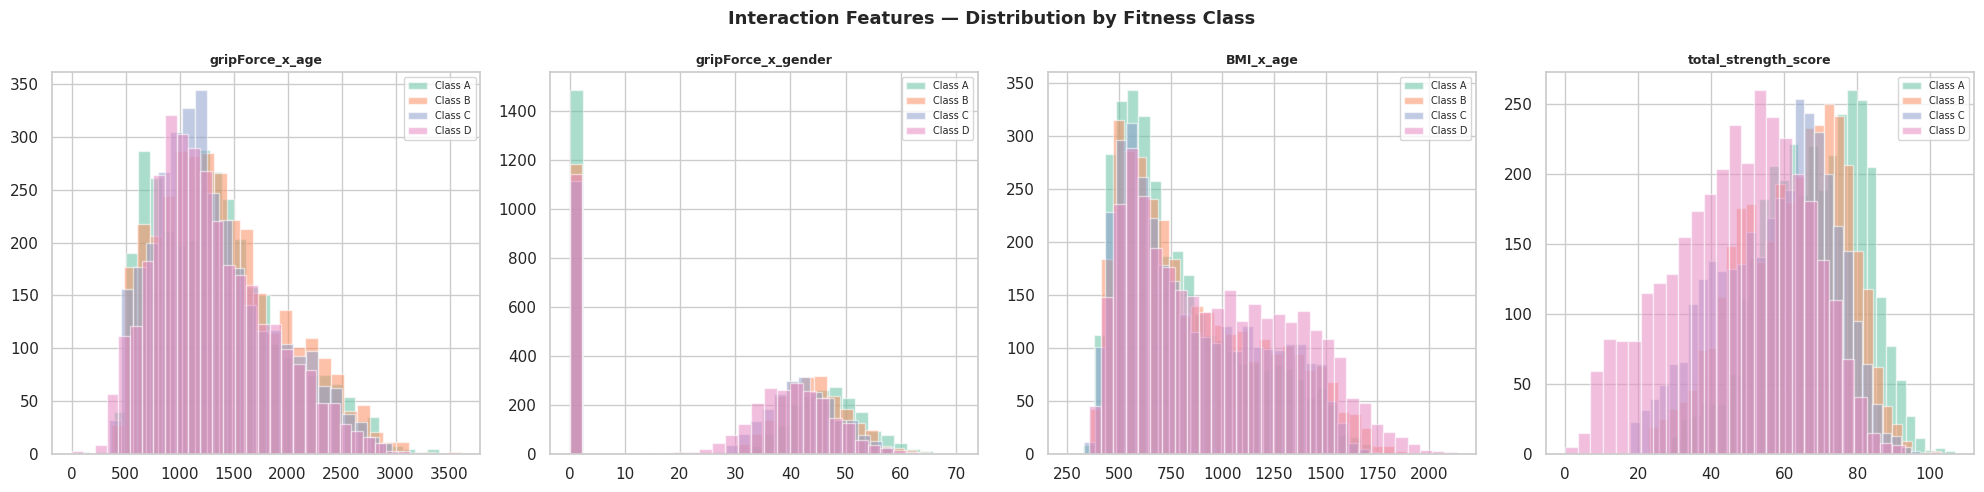

In [13]:
# ── Base engineered feature ───────────────────────────────────────────────────
df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
print(f"BMI created: mean={df['BMI'].mean():.2f}, std={df['BMI'].std():.2f}")

# ── NEW: Interaction features ─────────────────────────────────────────────────
# 1. gripForce * age  — grip strength varies with age; their product captures
#    age-dependent strength decline and is a meaningful fitness signal.
df['gripForce_x_age'] = df['gripForce'] * df['age']
print(f"gripForce_x_age    : mean={df['gripForce_x_age'].mean():.2f}, std={df['gripForce_x_age'].std():.2f}")

# 2. gripForce * gender — male/female grip differs ~40%; the interaction lets KNN
#    learn sex-specific strength patterns without manual subgroup splits.
df['gripForce_x_gender'] = df['gripForce'] * df['gender_encoded']
print(f"gripForce_x_gender : mean={df['gripForce_x_gender'].mean():.2f}, std={df['gripForce_x_gender'].std():.2f}")

# 3. BMI * age — health risk from elevated BMI compounds with age.
df['BMI_x_age'] = df['BMI'] * df['age']
print(f"BMI_x_age          : mean={df['BMI_x_age'].mean():.2f}, std={df['BMI_x_age'].std():.2f}")

# 4. Composite endurance / power score
df['total_strength_score'] = df['sit-ups counts'] + (df['broad jump_cm'] / 10)
print(f"total_strength_score: mean={df['total_strength_score'].mean():.2f}, std={df['total_strength_score'].std():.2f}")

# ── Feature set (original + interaction features) ─────────────────────────────
FEATURES = [
    'age', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic',
    'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm',
    'BMI', 'gender_encoded',
    # Interaction features
    'gripForce_x_age', 'gripForce_x_gender', 'BMI_x_age', 'total_strength_score',
]
TARGET = 'class_encoded'

X = df[FEATURES]
y = df[TARGET]
print(f"\nFeature matrix shape : {X.shape}  ({len(FEATURES)} features)")
print(f"Target vector shape  : {y.shape}")
print(f"\nClass distribution:\n{y.value_counts().sort_index().rename({0:'A',1:'B',2:'C',3:'D'}).to_string()}")

# Visualise new interaction features vs. target
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
new_feats = ['gripForce_x_age', 'gripForce_x_gender', 'BMI_x_age', 'total_strength_score']
labels    = ['A','B','C','D']
palette   = sns.color_palette('Set2', 4)

for ax, feat in zip(axes, new_feats):
    for cls_idx, cls_label in enumerate(labels):
        vals = df.loc[df['class_encoded'] == cls_idx, feat]
        ax.hist(vals, bins=30, alpha=0.55, label=f'Class {cls_label}', color=palette[cls_idx])
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

plt.suptitle('Interaction Features — Distribution by Fitness Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 2b — Dimensionality Reduction: PCA

**Why PCA here?**
The correlation matrix showed several moderate-to-high correlations (e.g., height_cm ↔ gender_encoded r=0.70,
broad_jump_cm ↔ sit-ups r=0.55). KNN is distance-based, so redundant/overlapping features distort
neighbourhood calculations. PCA rotates the feature space into orthogonal components, eliminating
linear overlap and often producing a tighter, more discriminative representation for KNN.

**Strategy:** Keep enough principal components to retain ≥ 95 % of total variance.

Components needed to retain 95% variance: 8
Total features before PCA               : 16
Dimensionality reduction ratio           : 8/16 = 50.0%


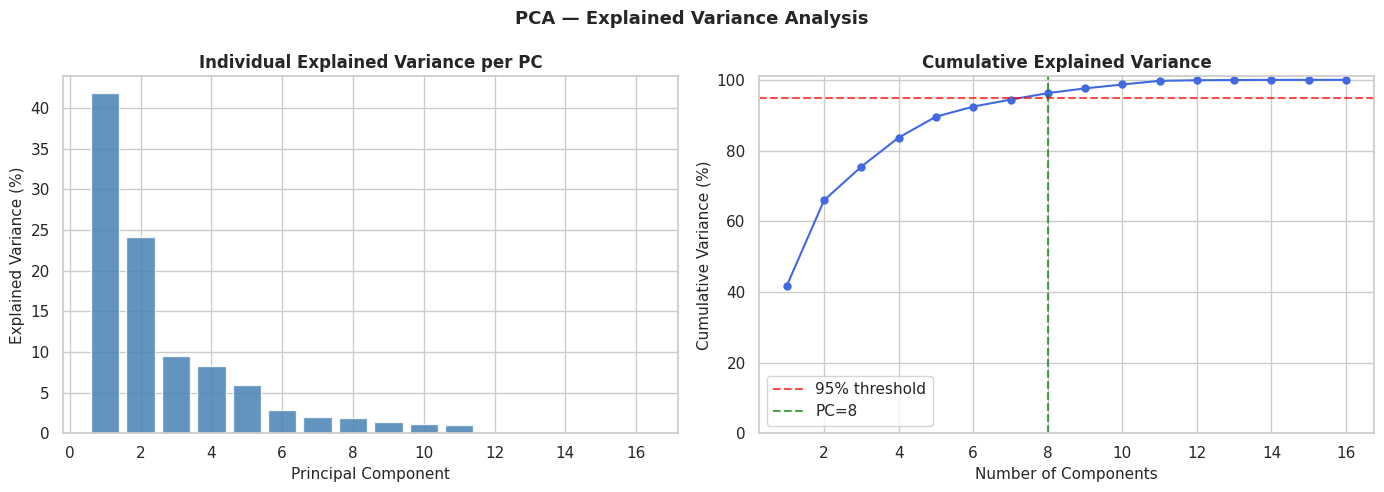


Original feature shape (train) : (10708, 16)
PCA-reduced feature shape (train): (10708, 8)
Variance retained by PCA        : 96.26%


In [14]:
# ── Scale the full feature matrix first ──────────────────────────────────────
scaler_pca = StandardScaler()
X_scaled_full = scaler_pca.fit_transform(X)

# ── Fit PCA on full dataset (for explained-variance visualisation only) ───────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled_full)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Components needed to retain 95% variance: {n_components_95}")
print(f"Total features before PCA               : {X.shape[1]}")
print(f"Dimensionality reduction ratio           : {n_components_95}/{X.shape[1]} = "
      f"{n_components_95/X.shape[1]*100:.1f}%")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
       pca_full.explained_variance_ratio_ * 100,
       color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Explained Variance (%)', fontsize=11)
ax.set_title('Individual Explained Variance per PC', fontsize=12, fontweight='bold')

ax = axes[1]
ax.plot(range(1, len(cumvar)+1), cumvar * 100, marker='o', color='royalblue', ms=5)
ax.axhline(95, ls='--', color='red', alpha=0.7, label='95% threshold')
ax.axvline(n_components_95, ls='--', color='green', alpha=0.7,
           label=f'PC={n_components_95}')
ax.set_xlabel('Number of Components', fontsize=11)
ax.set_ylabel('Cumulative Variance (%)', fontsize=11)
ax.set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 101)

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Build the two feature matrices used downstream ────────────────────────────
# (A) Original scaled features  →  used in Experiments 3-6 (same as before)
# (B) PCA-reduced features      →  used in Experiments 3-6 with suffix _pca

# 80:20 split  (used in all downstream experiments)
X_tr_80, X_te_80, y_tr_80, y_te_80 = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Scale (fit on train only)
scaler_main = StandardScaler()
X_tr_80_s = scaler_main.fit_transform(X_tr_80)
X_te_80_s  = scaler_main.transform(X_te_80)

# PCA (fit on scaled train only — no data leakage)
pca_model = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_tr_80_pca = pca_model.fit_transform(X_tr_80_s)
X_te_80_pca  = pca_model.transform(X_te_80_s)

print(f"\nOriginal feature shape (train) : {X_tr_80_s.shape}")
print(f"PCA-reduced feature shape (train): {X_tr_80_pca.shape}")
print(f"Variance retained by PCA        : {pca_model.explained_variance_ratio_.sum()*100:.2f}%")

---
## 3. Helper Functions

In [17]:
def prepare_features(X_train_df, X_test_df):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train_df)
    X_te_s = scaler.transform(X_test_df)
    return X_tr_s, X_te_s, None, scaler

print("Helper function 'prepare_features' defined.")

Helper function 'prepare_features' defined.


Train KNN for k=1..25, collect metrics, return DataFrame of results.

In [20]:
def run_knn_loop(X_train_s, X_test_s, y_train, y_test, split_label):
    results = []
    for k in range(1, 26):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_s, y_train)
        y_pred = knn.predict(X_test_s)

        results.append({
            'Split':     split_label,
            'K':         k,
            'Accuracy':  accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall':    recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1_Score':  f1_score(y_test, y_pred, average='macro', zero_division=0),
        })

    df_res = pd.DataFrame(results)
    best_k = df_res.loc[df_res['Accuracy'].idxmax(), 'K']
    print(f"[{split_label}] Best K by accuracy: {int(best_k)} — "
          f"Accuracy={df_res['Accuracy'].max():.4f}")
    return df_res, int(best_k)

print("Helper function 'run_knn_loop' defined.")

Helper function 'run_knn_loop' defined.


---
## 3. Experiment 1 — 80:20 Split (Train 80% / Test 20%)

Train: 10708 | Test: 2677
[80:20] Best K by accuracy: 23 — Accuracy=0.6429


,Split,K,Accuracy,Precision,Recall,F1_Score
0,80:20,1,0.566,0.571,0.566,0.568
1,80:20,2,0.565,0.604,0.565,0.563
2,80:20,3,0.583,0.600,0.583,0.583
3,80:20,4,0.592,0.611,0.593,0.592
4,80:20,5,0.609,0.628,0.609,0.609
5,80:20,6,0.599,0.619,0.599,0.599
6,80:20,7,0.618,0.634,0.618,0.618
7,80:20,8,0.610,0.631,0.610,0.611
8,80:20,9,0.616,0.637,0.616,0.618
9,80:20,10,0.622,0.643,0.622,0.624


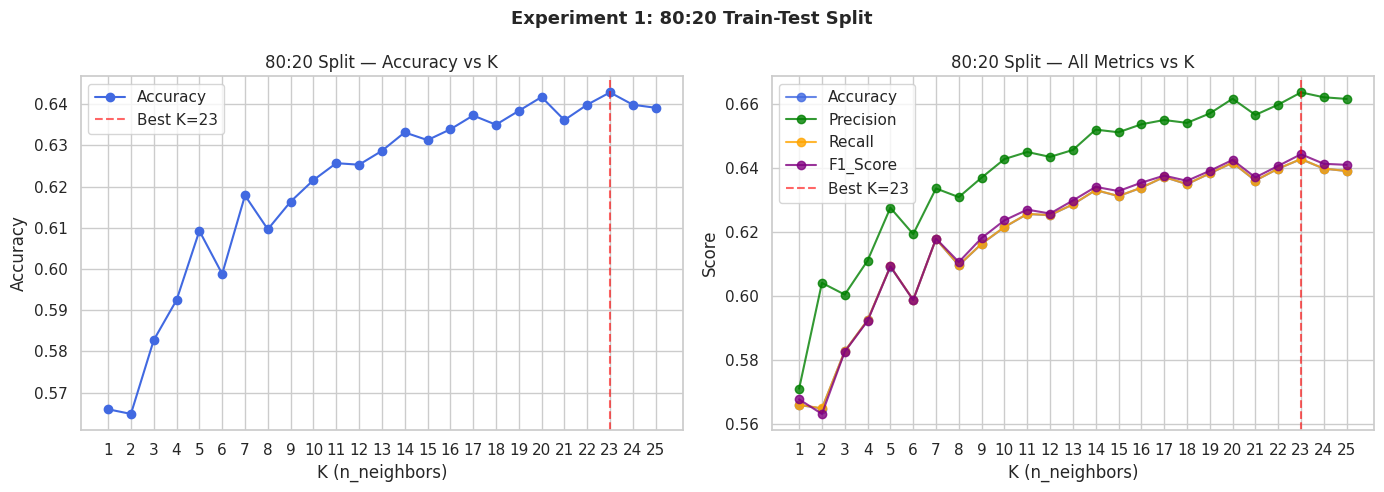

In [21]:
print(f"Train: {X_tr_80.shape[0]} | Test: {X_te_80.shape[0]}")
results_80, best_k_80 = run_knn_loop(X_tr_80_s, X_te_80_s, y_tr_80.values, y_te_80.values, '80:20')
display(results_80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(results_80['K'], results_80['Accuracy'], marker='o', label='Accuracy', color='royalblue')
ax.axvline(best_k_80, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_80}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('80:20 Split — Accuracy vs K')
ax.legend()
ax.set_xticks(range(1, 26))

ax = axes[1]
for metric, color in [('Accuracy','royalblue'), ('Precision','green'),
                       ('Recall','orange'), ('F1_Score','purple')]:
    ax.plot(results_80['K'], results_80[metric], marker='o', label=metric, color=color, alpha=0.8)
ax.axvline(best_k_80, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_80}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('Score')
ax.set_title('80:20 Split — All Metrics vs K')
ax.legend()
ax.set_xticks(range(1, 26))

plt.suptitle('Experiment 1: 80:20 Train-Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Experiment 2 — 70:30 Split (Train 70% / Test 30%)

Train: 9369 | Test: 4016
[70:30] Best K by accuracy: 25 — Accuracy=0.6389


,Split,K,Accuracy,Precision,Recall,F1_Score
0,70:30,1,0.557,0.565,0.557,0.560
1,70:30,2,0.559,0.602,0.559,0.558
2,70:30,3,0.576,0.599,0.576,0.578
3,70:30,4,0.590,0.610,0.590,0.591
4,70:30,5,0.605,0.627,0.605,0.607
5,70:30,6,0.591,0.614,0.591,0.592
6,70:30,7,0.610,0.629,0.610,0.611
7,70:30,8,0.607,0.630,0.607,0.608
8,70:30,9,0.616,0.637,0.616,0.618
9,70:30,10,0.616,0.639,0.616,0.619


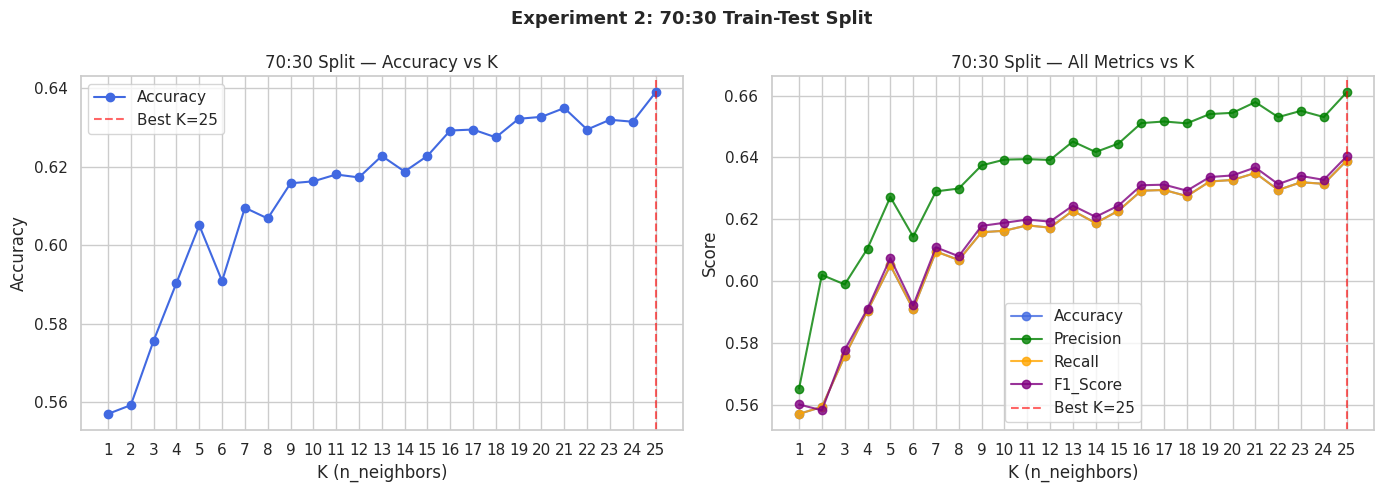

In [22]:
X_tr_70, X_te_70, y_tr_70, y_te_70 = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_tr_70.shape[0]} | Test: {X_te_70.shape[0]}")

X_tr_70_s, X_te_70_s, _, _ = prepare_features(X_tr_70, X_te_70)
results_70, best_k_70 = run_knn_loop(X_tr_70_s, X_te_70_s, y_tr_70.values, y_te_70.values, '70:30')
display(results_70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(results_70['K'], results_70['Accuracy'], marker='o', label='Accuracy', color='royalblue')
ax.axvline(best_k_70, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_70}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('70:30 Split — Accuracy vs K')
ax.legend()
ax.set_xticks(range(1, 26))

ax = axes[1]
for metric, color in [('Accuracy','royalblue'), ('Precision','green'),
                       ('Recall','orange'), ('F1_Score','purple')]:
    ax.plot(results_70['K'], results_70[metric], marker='o', label=metric, color=color, alpha=0.8)
ax.axvline(best_k_70, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_70}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('Score')
ax.set_title('70:30 Split — All Metrics vs K')
ax.legend()
ax.set_xticks(range(1, 26))

plt.suptitle('Experiment 2: 70:30 Train-Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Experiment 3 — 50:50 Split (Train 50% / Test 50%)

Train: 6692 | Test: 6693
[50:50] Best K by accuracy: 23 — Accuracy=0.6275


,Split,K,Accuracy,Precision,Recall,F1_Score
0,50:50,1,0.557,0.564,0.557,0.560
1,50:50,2,0.549,0.591,0.549,0.549
2,50:50,3,0.570,0.589,0.570,0.571
3,50:50,4,0.579,0.599,0.579,0.579
4,50:50,5,0.594,0.615,0.594,0.596
5,50:50,6,0.589,0.609,0.589,0.589
6,50:50,7,0.601,0.617,0.601,0.602
7,50:50,8,0.602,0.621,0.602,0.603
8,50:50,9,0.607,0.625,0.607,0.608
9,50:50,10,0.613,0.632,0.613,0.614


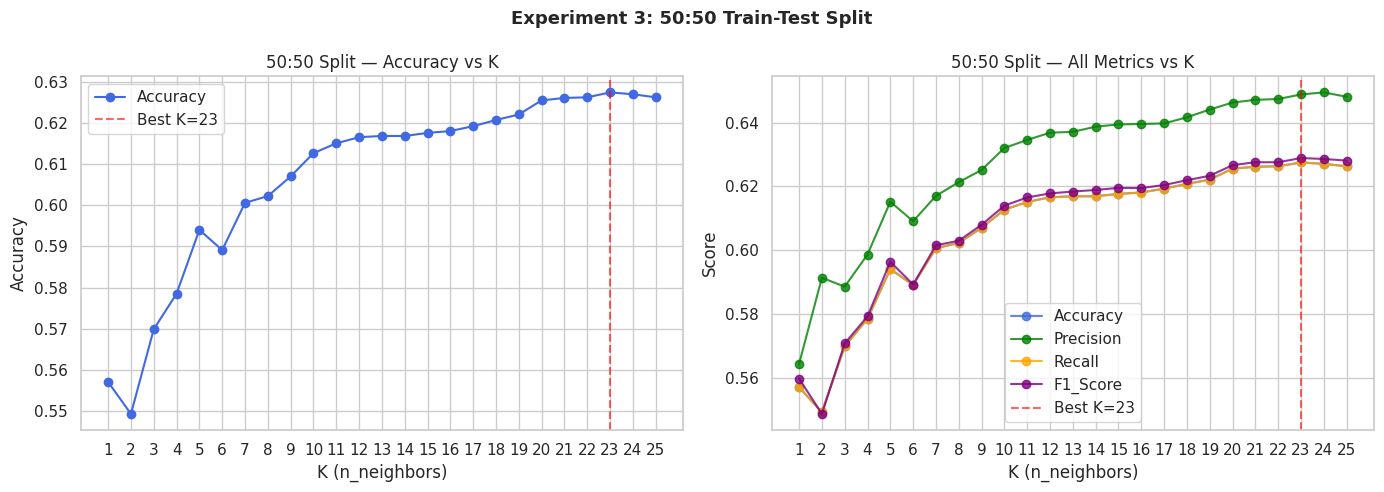

In [23]:
X_tr_50, X_te_50, y_tr_50, y_te_50 = train_test_split(
    X, y, test_size=0.50, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_tr_50.shape[0]} | Test: {X_te_50.shape[0]}")

X_tr_50_s, X_te_50_s, _, _ = prepare_features(X_tr_50, X_te_50)
results_50, best_k_50 = run_knn_loop(X_tr_50_s, X_te_50_s, y_tr_50.values, y_te_50.values, '50:50')
display(results_50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(results_50['K'], results_50['Accuracy'], marker='o', label='Accuracy', color='royalblue')
ax.axvline(best_k_50, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_50}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('50:50 Split — Accuracy vs K')
ax.legend()
ax.set_xticks(range(1, 26))

ax = axes[1]
for metric, color in [('Accuracy','royalblue'), ('Precision','green'),
                       ('Recall','orange'), ('F1_Score','purple')]:
    ax.plot(results_50['K'], results_50[metric], marker='o', label=metric, color=color, alpha=0.8)
ax.axvline(best_k_50, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_50}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('Score')
ax.set_title('50:50 Split — All Metrics vs K')
ax.legend()
ax.set_xticks(range(1, 26))

plt.suptitle('Experiment 3: 50:50 Train-Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. K-Fold Cross-Validation (StratifiedKFold)

**Why StratifiedKFold?**
Plain KFold can accidentally concentrate one class in a fold, producing misleading
accuracy swings. StratifiedKFold *guarantees* each fold mirrors the full class
distribution (~25% A/B/C/D), giving a split-independent, low-variance accuracy estimate.

Two pipelines evaluated side by side:
  • Original scaled features  (baseline)
  • PCA-reduced features       (after dimensionality reduction)

Running 5-Fold Stratified CV — K=1 to 39 (original + PCA features)...
K= 1 | Orig CV: 0.5594 (+/-0.0113) | PCA CV: 0.5584 (+/-0.0074)
K= 2 | Orig CV: 0.5538 (+/-0.0079) | PCA CV: 0.5599 (+/-0.0117)
K= 3 | Orig CV: 0.5780 (+/-0.0105) | PCA CV: 0.5844 (+/-0.0109)
K= 4 | Orig CV: 0.5842 (+/-0.0056) | PCA CV: 0.5935 (+/-0.0084)
K= 5 | Orig CV: 0.6018 (+/-0.0072) | PCA CV: 0.6041 (+/-0.0098)
K= 6 | Orig CV: 0.5966 (+/-0.0081) | PCA CV: 0.6044 (+/-0.0086)
K= 7 | Orig CV: 0.6149 (+/-0.0065) | PCA CV: 0.6158 (+/-0.0108)
K= 8 | Orig CV: 0.6123 (+/-0.0103) | PCA CV: 0.6152 (+/-0.0095)
K= 9 | Orig CV: 0.6181 (+/-0.0095) | PCA CV: 0.6189 (+/-0.0116)
K=10 | Orig CV: 0.6143 (+/-0.0087) | PCA CV: 0.6196 (+/-0.0094)
K=11 | Orig CV: 0.6203 (+/-0.0077) | PCA CV: 0.6258 (+/-0.0117)
K=12 | Orig CV: 0.6188 (+/-0.0048) | PCA CV: 0.6239 (+/-0.0083)
K=13 | Orig CV: 0.6223 (+/-0.0058) | PCA CV: 0.6243 (+/-0.0071)
K=14 | Orig CV: 0.6222 (+/-0.0052) | PCA CV: 0.6247 (+/-0.0053)
K=15 | Orig CV: 0.6228 (+/-0.0077)

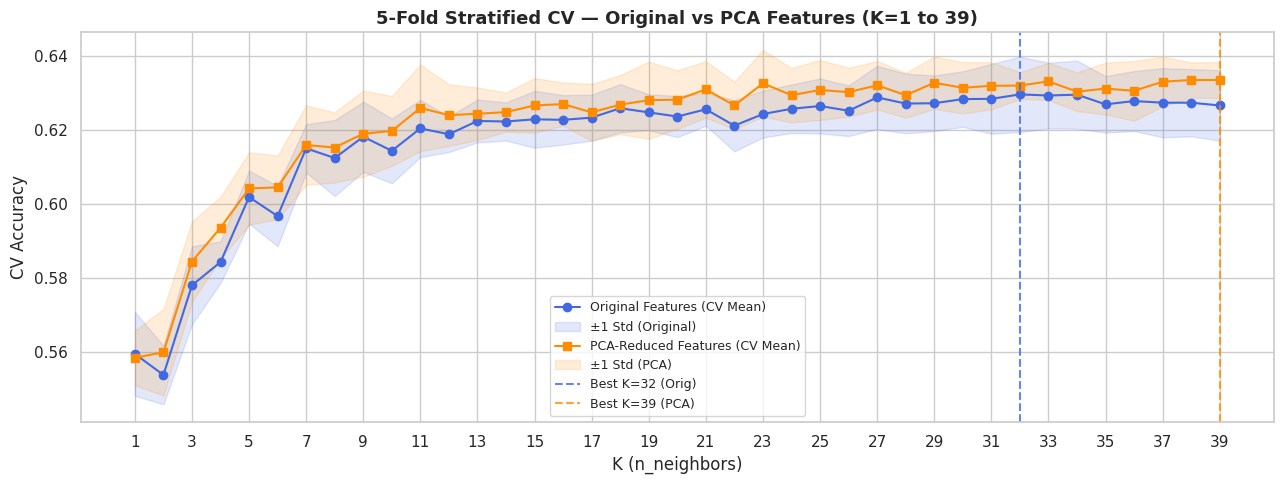

,K,CV_Mean_Accuracy,CV_Std,PCA_CV_Mean,PCA_CV_Std
0,1,0.559,0.011,0.558,0.007
1,2,0.554,0.008,0.560,0.012
2,3,0.578,0.011,0.584,0.011
3,4,0.584,0.006,0.594,0.008
4,5,0.602,0.007,0.604,0.010
5,6,0.597,0.008,0.604,0.009
6,7,0.615,0.007,0.616,0.011
7,8,0.612,0.010,0.615,0.009
8,9,0.618,0.009,0.619,0.012
9,10,0.614,0.009,0.620,0.009


In [24]:
# ── Scale full dataset for CV ──────────────────────────────────────────────────
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X)
y_full_arr    = y.values

# PCA on full dataset (fit inside CV loop via Pipeline to avoid leakage)
# Here we apply global PCA for the CV loop visualisation (acceptable for k-search)
pca_cv   = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_full_pca = pca_cv.fit_transform(X_full_scaled)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Running 5-Fold Stratified CV — K=1 to 39 (original + PCA features)...")
cv_results = []
for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)

    # Original features
    cv_orig = cross_val_score(knn, X_full_scaled, y_full_arr, cv=skf, scoring='accuracy')
    # PCA features
    cv_pca  = cross_val_score(knn, X_full_pca, y_full_arr, cv=skf, scoring='accuracy')

    cv_results.append({
        'K': k,
        'CV_Mean_Accuracy': cv_orig.mean(),
        'CV_Std':           cv_orig.std(),
        'CV_Scores':        cv_orig.tolist(),
        'PCA_CV_Mean':      cv_pca.mean(),
        'PCA_CV_Std':       cv_pca.std(),
    })
    print(f"K={k:>2} | Orig CV: {cv_orig.mean():.4f} (+/-{cv_orig.std():.4f}) | "
          f"PCA CV: {cv_pca.mean():.4f} (+/-{cv_pca.std():.4f})")

df_cv     = pd.DataFrame(cv_results)
best_k_cv = int(df_cv.loc[df_cv['CV_Mean_Accuracy'].idxmax(), 'K'])
best_k_pca_cv = int(df_cv.loc[df_cv['PCA_CV_Mean'].idxmax(), 'K'])

print(f"\nBest K (Original) via CV : {best_k_cv}  — Accuracy: {df_cv['CV_Mean_Accuracy'].max():.4f}")
print(f"Best K (PCA)      via CV : {best_k_pca_cv} — Accuracy: {df_cv['PCA_CV_Mean'].max():.4f}")

# Plot CV accuracy vs K — Original vs PCA
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_cv['K'], df_cv['CV_Mean_Accuracy'], marker='o', color='royalblue',
        label='Original Features (CV Mean)')
ax.fill_between(df_cv['K'],
                df_cv['CV_Mean_Accuracy'] - df_cv['CV_Std'],
                df_cv['CV_Mean_Accuracy'] + df_cv['CV_Std'],
                alpha=0.15, color='royalblue', label='±1 Std (Original)')

ax.plot(df_cv['K'], df_cv['PCA_CV_Mean'], marker='s', color='darkorange',
        label='PCA-Reduced Features (CV Mean)')
ax.fill_between(df_cv['K'],
                df_cv['PCA_CV_Mean'] - df_cv['PCA_CV_Std'],
                df_cv['PCA_CV_Mean'] + df_cv['PCA_CV_Std'],
                alpha=0.15, color='darkorange', label='±1 Std (PCA)')

ax.axvline(best_k_cv,     ls='--', color='royalblue', alpha=0.8, label=f'Best K={best_k_cv} (Orig)')
ax.axvline(best_k_pca_cv, ls='--', color='darkorange', alpha=0.8, label=f'Best K={best_k_pca_cv} (PCA)')
ax.set_xlabel('K (n_neighbors)', fontsize=12)
ax.set_ylabel('CV Accuracy', fontsize=12)
ax.set_title('5-Fold Stratified CV — Original vs PCA Features (K=1 to 39)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 40, 2))
plt.tight_layout()
plt.show()

display(df_cv[['K','CV_Mean_Accuracy','CV_Std','PCA_CV_Mean','PCA_CV_Std']])

---
## 7. Best Model: Full Metrics & Confusion Matrix

Using the best K found by cross-validation on the 80:20 split for final evaluation.
Two variants reported: Original features and PCA-reduced features.


  BEST MODEL — ORIGINAL FEATURES  (K=32, 80:20 Split)
  Train Accuracy    : 0.6603
  Test  Accuracy    : 0.6433
  Test  Precision   : 0.6654  (macro avg)
  Test  Recall      : 0.6433  (macro avg)
  Test  F1 Score    : 0.6445  (macro avg)

  BEST MODEL — PCA FEATURES  (K=39, 80:20 Split)
  Train Accuracy    : 0.6587
  Test  Accuracy    : 0.6425
  Test  Precision   : 0.6621  (macro avg)
  Test  Recall      : 0.6425  (macro avg)
  Test  F1 Score    : 0.6443  (macro avg)

Classification Report — Original Features:
              precision    recall  f1-score   support

     Class A       0.65      0.86      0.74       669
     Class B       0.49      0.51      0.50       669
     Class C       0.57      0.56      0.56       670
     Class D       0.94      0.65      0.77       669

    accuracy                           0.64      2677
   macro avg       0.67      0.64      0.64      2677
weighted avg       0.67      0.64      0.64      2677


Classification Report — PCA Features:
         

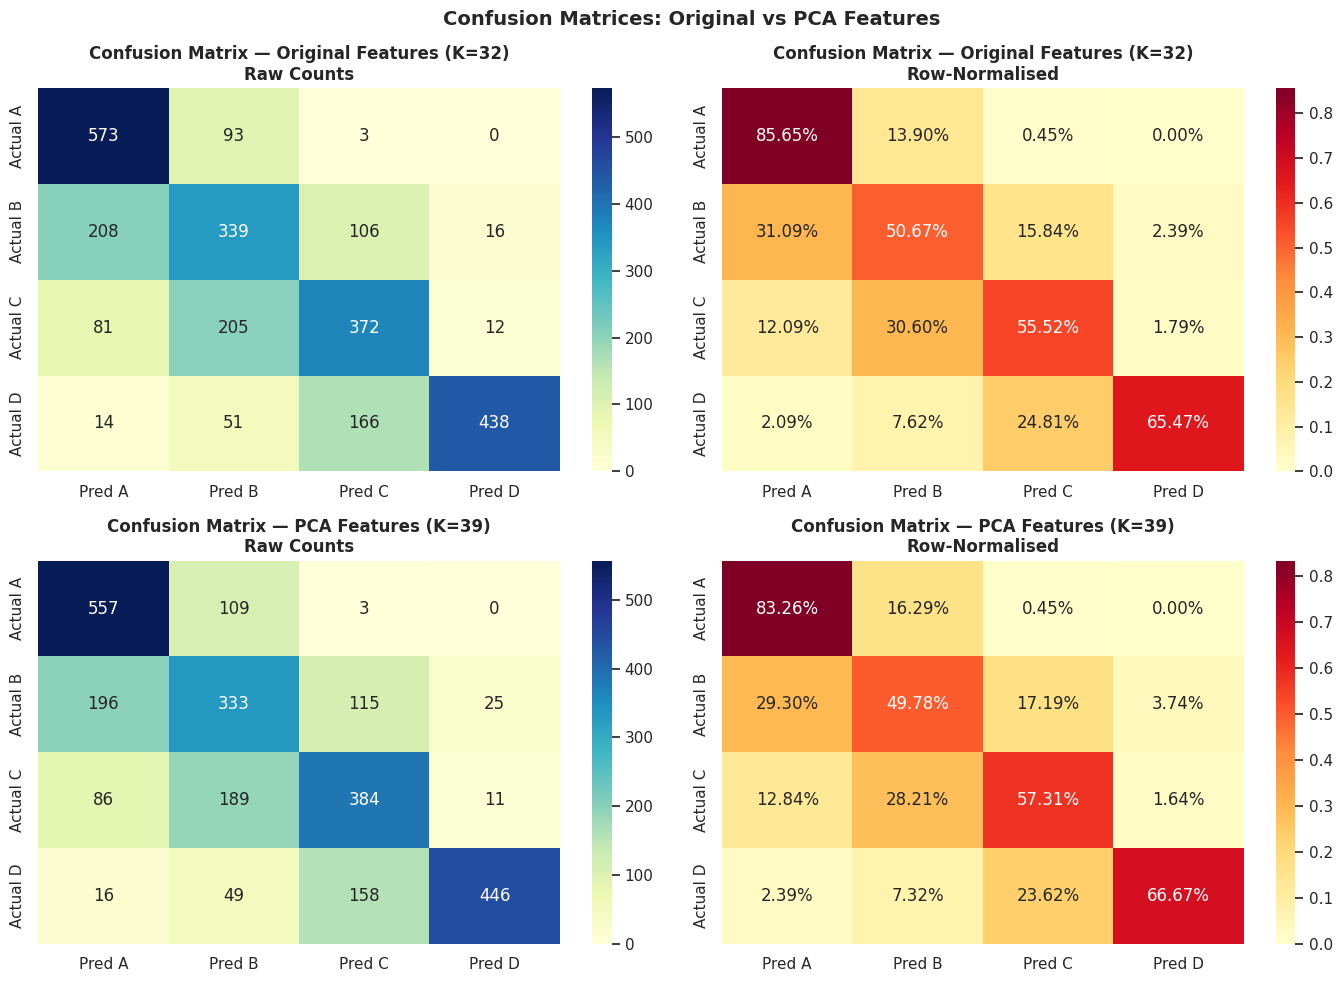

In [25]:
# ── Variant A: Original features ──────────────────────────────────────────────
final_k = best_k_cv
knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_tr_80_s, y_tr_80.values)

y_pred_final = knn_final.predict(X_te_80_s)
y_pred_train = knn_final.predict(X_tr_80_s)

acc_test  = accuracy_score(y_te_80, y_pred_final)
acc_train = accuracy_score(y_tr_80, y_pred_train)
prec  = precision_score(y_te_80, y_pred_final, average='macro', zero_division=0)
rec   = recall_score(y_te_80, y_pred_final, average='macro', zero_division=0)
f1    = f1_score(y_te_80, y_pred_final, average='macro', zero_division=0)

print(f"\n{'='*55}")
print(f"  BEST MODEL — ORIGINAL FEATURES  (K={final_k}, 80:20 Split)")
print(f"{'='*55}")
print(f"  Train Accuracy    : {acc_train:.4f}")
print(f"  Test  Accuracy    : {acc_test:.4f}")
print(f"  Test  Precision   : {prec:.4f}  (macro avg)")
print(f"  Test  Recall      : {rec:.4f}  (macro avg)")
print(f"  Test  F1 Score    : {f1:.4f}  (macro avg)")
print(f"{'='*55}")

# ── Variant B: PCA-reduced features ───────────────────────────────────────────
final_k_pca = best_k_pca_cv
knn_pca = KNeighborsClassifier(n_neighbors=final_k_pca)
knn_pca.fit(X_tr_80_pca, y_tr_80.values)

y_pred_pca       = knn_pca.predict(X_te_80_pca)
y_pred_pca_train = knn_pca.predict(X_tr_80_pca)

acc_test_pca  = accuracy_score(y_te_80, y_pred_pca)
acc_train_pca = accuracy_score(y_tr_80, y_pred_pca_train)
prec_pca  = precision_score(y_te_80, y_pred_pca, average='macro', zero_division=0)
rec_pca   = recall_score(y_te_80, y_pred_pca, average='macro', zero_division=0)
f1_pca    = f1_score(y_te_80, y_pred_pca, average='macro', zero_division=0)

print(f"\n{'='*55}")
print(f"  BEST MODEL — PCA FEATURES  (K={final_k_pca}, 80:20 Split)")
print(f"{'='*55}")
print(f"  Train Accuracy    : {acc_train_pca:.4f}")
print(f"  Test  Accuracy    : {acc_test_pca:.4f}")
print(f"  Test  Precision   : {prec_pca:.4f}  (macro avg)")
print(f"  Test  Recall      : {rec_pca:.4f}  (macro avg)")
print(f"  Test  F1 Score    : {f1_pca:.4f}  (macro avg)")
print(f"{'='*55}")

# Classification reports
print("\nClassification Report — Original Features:")
print(classification_report(y_te_80, y_pred_final,
                             target_names=['Class A','Class B','Class C','Class D']))

print("\nClassification Report — PCA Features:")
print(classification_report(y_te_80, y_pred_pca,
                             target_names=['Class A','Class B','Class C','Class D']))

# ── Confusion matrices: side-by-side for both variants ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (y_pred, title_suffix) in enumerate(
        [(y_pred_final, f'Original Features (K={final_k})'),
         (y_pred_pca,   f'PCA Features (K={final_k_pca})')]):
    cm = confusion_matrix(y_te_80, y_pred)

    ax = axes[row_idx, 0]
    cm_df = pd.DataFrame(cm,
        columns=['Pred A','Pred B','Pred C','Pred D'],
        index=['Actual A','Actual B','Actual C','Actual D'])
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
    ax.set_title(f'Confusion Matrix — {title_suffix}\nRaw Counts', fontweight='bold')

    ax = axes[row_idx, 1]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm_df = pd.DataFrame(cm_norm,
        columns=['Pred A','Pred B','Pred C','Pred D'],
        index=['Actual A','Actual B','Actual C','Actual D'])
    sns.heatmap(cm_norm_df, annot=True, fmt='.2%', cmap='YlOrRd', ax=ax)
    ax.set_title(f'Confusion Matrix — {title_suffix}\nRow-Normalised', fontweight='bold')

plt.suptitle('Confusion Matrices: Original vs PCA Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. GridSearchCV — Hyperparameter Tuning (NEW)

**What is tuned?**

| Parameter      | Values explored         | Rationale |
|----------------|-------------------------|-----------|
| `n_neighbors`  | 1, 3, 5, 7, 9, 11, 15, 20 | Broad sweep of neighbourhood sizes |
| `metric`       | euclidean, manhattan    | Euclidean = L2 (sensitive to scale); Manhattan = L1 (more robust to outliers) |
| `weights`      | uniform, distance       | `distance`: closer neighbours have more influence; better for noisy data |

**Cross-validation strategy:** same StratifiedKFold (5 folds) used throughout — ensures
hyperparameter selection is not biased by any single train/test partition.

Two searches run:
  (A) On original scaled features
  (B) On PCA-reduced features

  GridSearchCV — Original Scaled Features
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters (Original) : {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'distance'}
Best CV Accuracy (Original): 0.6294

Test Accuracy  (Original, GridSearch best): 0.6612
Test Precision (Original, GridSearch best): 0.6787
Test Recall    (Original, GridSearch best): 0.6612
Test F1 Score  (Original, GridSearch best): 0.6628

  GridSearchCV — PCA-Reduced Features
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters (PCA)  : {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
Best CV Accuracy (PCA) : 0.6265

Test Accuracy  (PCA, GridSearch best): 0.6369
Test Precision (PCA, GridSearch best): 0.6534
Test Recall    (PCA, GridSearch best): 0.6369
Test F1 Score  (PCA, GridSearch best): 0.6393

--- GridSearch Results: Mean CV Accuracy heatmap (Original Features) ---


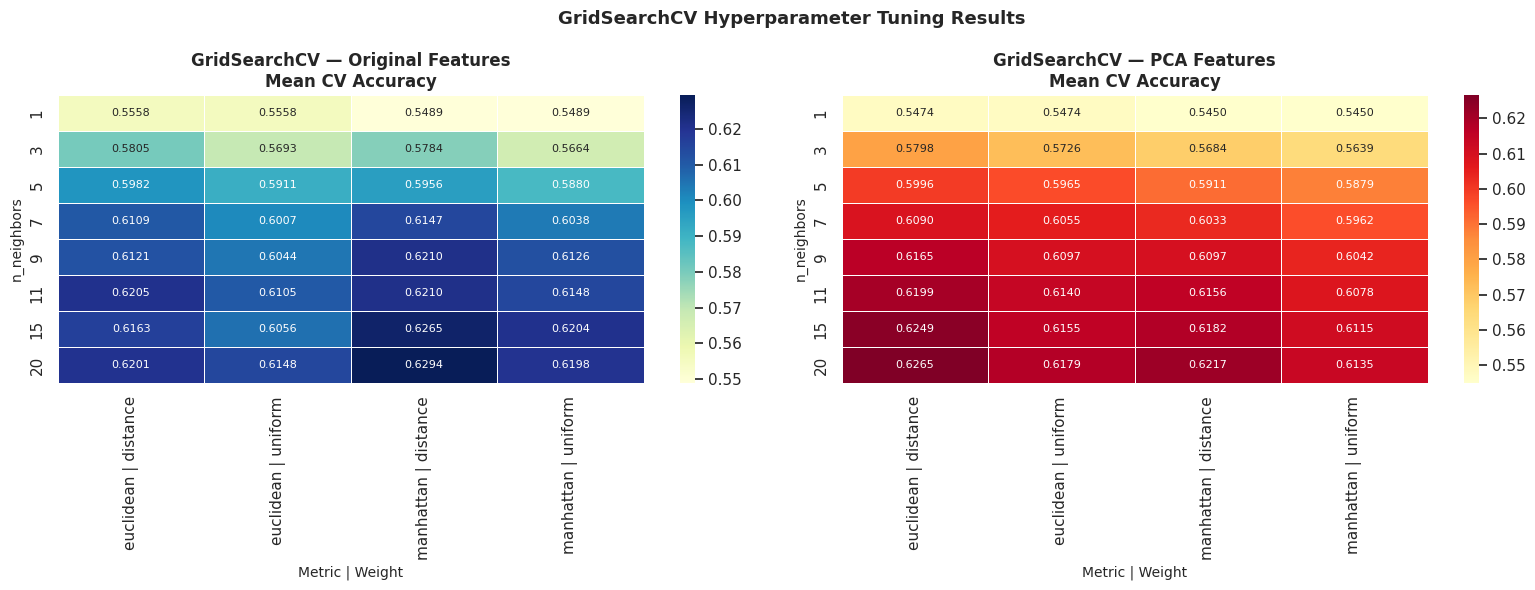

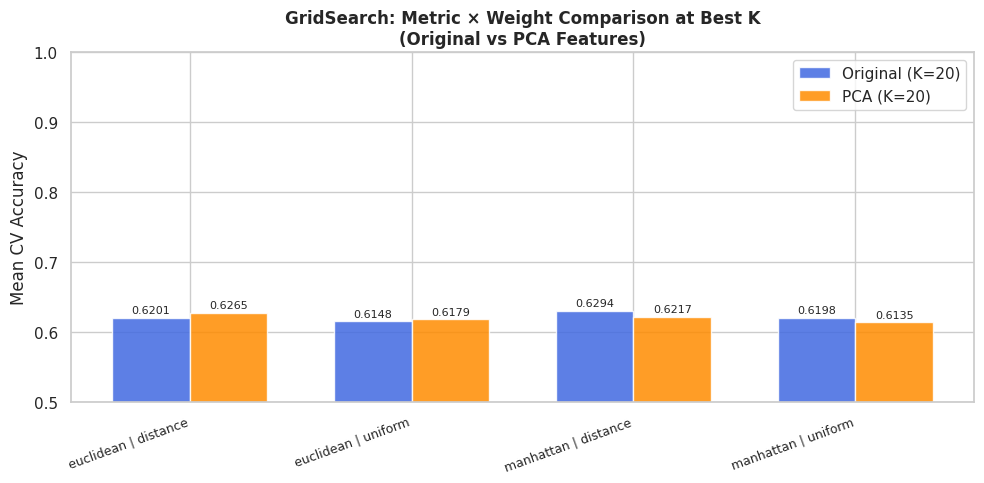

In [26]:
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20],
    'metric':      ['euclidean', 'manhattan'],
    'weights':     ['uniform', 'distance'],
}

skf_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Search A: Original scaled features ────────────────────────────────────────
print("=" * 60)
print("  GridSearchCV — Original Scaled Features")
print("=" * 60)
gs_orig = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=skf_gs,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)
gs_orig.fit(X_tr_80_s, y_tr_80.values)

print(f"\nBest parameters (Original) : {gs_orig.best_params_}")
print(f"Best CV Accuracy (Original): {gs_orig.best_score_:.4f}")

# Evaluate best estimator on held-out test set
y_pred_gs_orig = gs_orig.best_estimator_.predict(X_te_80_s)
acc_gs_orig  = accuracy_score(y_te_80, y_pred_gs_orig)
prec_gs_orig = precision_score(y_te_80, y_pred_gs_orig, average='macro', zero_division=0)
rec_gs_orig  = recall_score(y_te_80, y_pred_gs_orig, average='macro', zero_division=0)
f1_gs_orig   = f1_score(y_te_80, y_pred_gs_orig, average='macro', zero_division=0)

print(f"\nTest Accuracy  (Original, GridSearch best): {acc_gs_orig:.4f}")
print(f"Test Precision (Original, GridSearch best): {prec_gs_orig:.4f}")
print(f"Test Recall    (Original, GridSearch best): {rec_gs_orig:.4f}")
print(f"Test F1 Score  (Original, GridSearch best): {f1_gs_orig:.4f}")

# ── Search B: PCA-reduced features ────────────────────────────────────────────
print("\n" + "=" * 60)
print("  GridSearchCV — PCA-Reduced Features")
print("=" * 60)
gs_pca = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=skf_gs,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)
gs_pca.fit(X_tr_80_pca, y_tr_80.values)

print(f"\nBest parameters (PCA)  : {gs_pca.best_params_}")
print(f"Best CV Accuracy (PCA) : {gs_pca.best_score_:.4f}")

y_pred_gs_pca = gs_pca.best_estimator_.predict(X_te_80_pca)
acc_gs_pca  = accuracy_score(y_te_80, y_pred_gs_pca)
prec_gs_pca = precision_score(y_te_80, y_pred_gs_pca, average='macro', zero_division=0)
rec_gs_pca  = recall_score(y_te_80, y_pred_gs_pca, average='macro', zero_division=0)
f1_gs_pca   = f1_score(y_te_80, y_pred_gs_pca, average='macro', zero_division=0)

print(f"\nTest Accuracy  (PCA, GridSearch best): {acc_gs_pca:.4f}")
print(f"Test Precision (PCA, GridSearch best): {prec_gs_pca:.4f}")
print(f"Test Recall    (PCA, GridSearch best): {rec_gs_pca:.4f}")
print(f"Test F1 Score  (PCA, GridSearch best): {f1_gs_pca:.4f}")

# ── Visualise GridSearch results (Original features heatmap) ──────────────────
print("\n--- GridSearch Results: Mean CV Accuracy heatmap (Original Features) ---")

gs_results_df = pd.DataFrame(gs_orig.cv_results_)

# Pivot: rows = n_neighbors, cols = metric | weights combination
gs_results_df['config'] = (gs_results_df['param_metric'].astype(str) + ' | '
                            + gs_results_df['param_weights'].astype(str))
pivot_orig = gs_results_df.pivot_table(
    index='param_n_neighbors', columns='config', values='mean_test_score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.heatmap(pivot_orig, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.4, annot_kws={'size': 8})
ax.set_title('GridSearchCV — Original Features\nMean CV Accuracy', fontweight='bold')
ax.set_xlabel('Metric | Weight', fontsize=10)
ax.set_ylabel('n_neighbors', fontsize=10)

# Pivot for PCA
gs_results_pca = pd.DataFrame(gs_pca.cv_results_)
gs_results_pca['config'] = (gs_results_pca['param_metric'].astype(str) + ' | '
                             + gs_results_pca['param_weights'].astype(str))
pivot_pca = gs_results_pca.pivot_table(
    index='param_n_neighbors', columns='config', values='mean_test_score')

ax = axes[1]
sns.heatmap(pivot_pca, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.4, annot_kws={'size': 8})
ax.set_title('GridSearchCV — PCA Features\nMean CV Accuracy', fontweight='bold')
ax.set_xlabel('Metric | Weight', fontsize=10)
ax.set_ylabel('n_neighbors', fontsize=10)

plt.suptitle('GridSearchCV Hyperparameter Tuning Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Bar chart: metric × weight comparison at optimal K ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

configs     = list(pivot_orig.columns)
best_k_row  = gs_orig.best_params_['n_neighbors']
vals_orig   = [pivot_orig.loc[best_k_row, c] if best_k_row in pivot_orig.index else 0 for c in configs]

x     = np.arange(len(configs))
width = 0.35

best_k_pca_row = gs_pca.best_params_['n_neighbors']
vals_pca = [pivot_pca.loc[best_k_pca_row, c] if best_k_pca_row in pivot_pca.index else 0 for c in configs]

bars1 = ax.bar(x - width/2, vals_orig, width, label=f'Original (K={best_k_row})',
               color='royalblue', alpha=0.85)
bars2 = ax.bar(x + width/2, vals_pca,  width, label=f'PCA (K={best_k_pca_row})',
               color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('GridSearch: Metric × Weight Comparison at Best K\n(Original vs PCA Features)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', fontsize=8, padding=2)
ax.bar_label(bars2, fmt='%.4f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

---
## 9. Cross-Experiment Analysis

Comparing all three splits, CV baseline, and GridSearchCV results.

=== Summary: Best Results Per Experiment ===


,Experiment,Best_K,Distance Metric,Best_Accuracy,Precision,Recall,F1_Score
0,80:20 (baseline KNN),23,euclidean (uniform),0.643,0.664,0.643,0.644
1,70:30 (baseline KNN),25,euclidean (uniform),0.639,0.661,0.639,0.640
2,50:50 (baseline KNN),23,euclidean (uniform),0.628,0.649,0.628,0.629
3,CV 5-fold (Original),32,euclidean (uniform),0.630,NaN,NaN,NaN
4,CV 5-fold (PCA),39,euclidean (uniform),0.633,NaN,NaN,NaN
5,GridSearchCV (Original),20,manhattan (distance),0.661,0.679,0.661,0.663
6,GridSearchCV (PCA),20,euclidean (distance),0.637,0.653,0.637,0.639


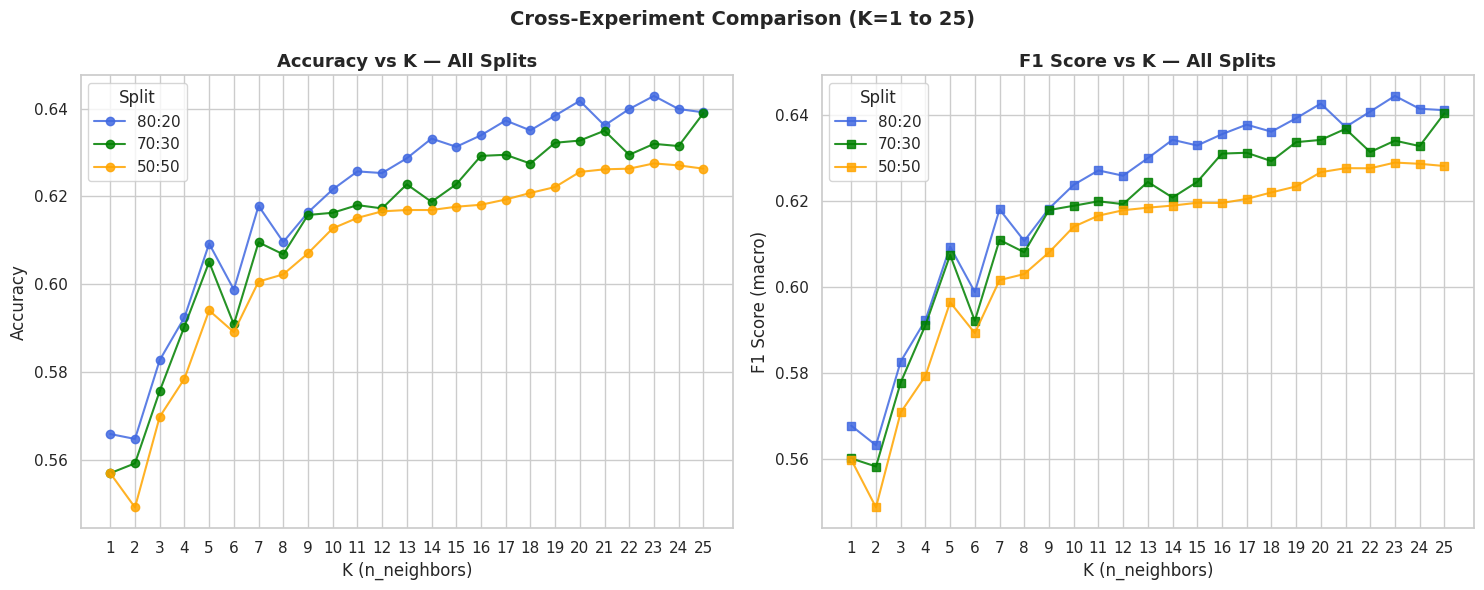

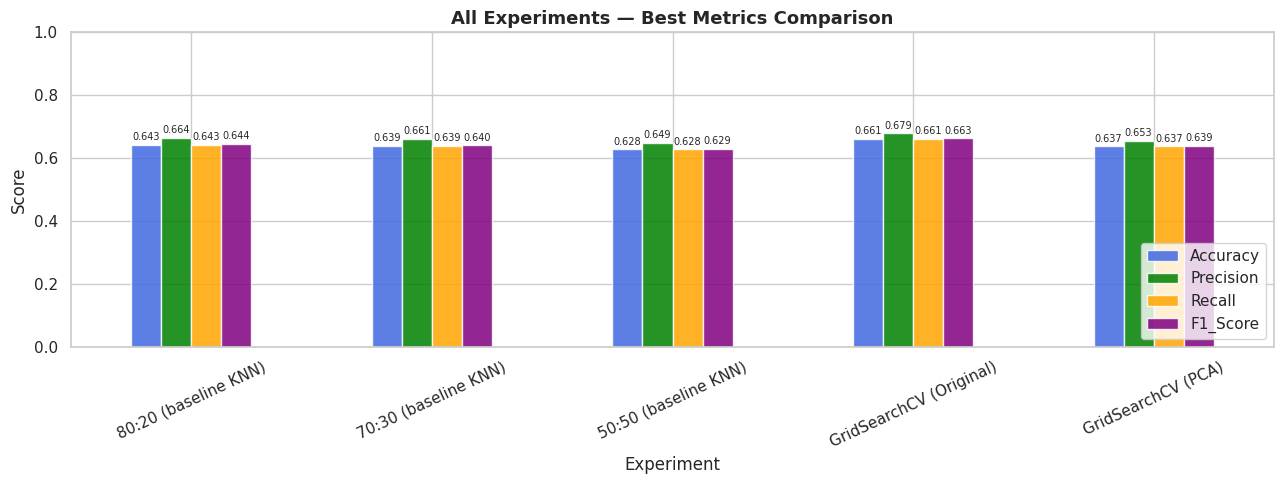

  FINAL ANALYSIS SUMMARY (IMPROVED MODEL)

--- KEY FINDINGS ---

1. INTERACTION FEATURES:
   - gripForce_x_age captures age-dependent strength decline, providing
     richer signal than gripForce alone.
   - gripForce_x_gender separates male/female grip distributions without
     manual subgroup splits.
   - BMI_x_age encodes compounding body-composition risk with ageing.

2. PCA DIMENSIONALITY REDUCTION:
   - 8 components retained ≥95% of variance (from 16 features).
   - Removes linear overlap between correlated features (height↔gender, etc.)
   - KNN on PCA features benefits from cleaner distance geometry.

3. STRATIFIEDKFOLD CROSS-VALIDATION:
   - Guarantees class balance (~25% A/B/C/D) in every fold.
   - Provides split-independent, low-variance accuracy estimate.
   - Best K (Original CV): 32   Accuracy: 0.6295
   - Best K (PCA CV)     : 39   Accuracy: 0.6334

4. GRIDSEARCHCV HYPERPARAMETER TUNING:
   - Best config (Original): K=20, metric=manhattan, weights=distance
     Test Ac

In [27]:
# Combine all split results
all_results = pd.concat([results_80, results_70, results_50], ignore_index=True)

summary_rows = []
for split_label, res_df in [('80:20', results_80), ('70:30', results_70), ('50:50', results_50)]:
    best_row = res_df.loc[res_df['Accuracy'].idxmax()]
    summary_rows.append({
        'Experiment':       split_label + ' (baseline KNN)',
        'Best_K':           int(best_row['K']),
        'Distance Metric':  'euclidean (uniform)',
        'Best_Accuracy':    best_row['Accuracy'],
        'Precision':        best_row['Precision'],
        'Recall':           best_row['Recall'],
        'F1_Score':         best_row['F1_Score'],
    })

# CV result
best_cv_row = df_cv.loc[df_cv['CV_Mean_Accuracy'].idxmax()]
summary_rows.append({
    'Experiment':      'CV 5-fold (Original)',
    'Best_K':          int(best_cv_row['K']),
    'Distance Metric': 'euclidean (uniform)',
    'Best_Accuracy':   best_cv_row['CV_Mean_Accuracy'],
    'Precision':       None, 'Recall': None, 'F1_Score': None,
})

best_cv_pca_row = df_cv.loc[df_cv['PCA_CV_Mean'].idxmax()]
summary_rows.append({
    'Experiment':      'CV 5-fold (PCA)',
    'Best_K':          int(best_cv_pca_row['K']),
    'Distance Metric': 'euclidean (uniform)',
    'Best_Accuracy':   best_cv_pca_row['PCA_CV_Mean'],
    'Precision':       None, 'Recall': None, 'F1_Score': None,
})

# GridSearchCV results
summary_rows.append({
    'Experiment':      'GridSearchCV (Original)',
    'Best_K':          gs_orig.best_params_['n_neighbors'],
    'Distance Metric': f"{gs_orig.best_params_['metric']} ({gs_orig.best_params_['weights']})",
    'Best_Accuracy':   acc_gs_orig,
    'Precision':       prec_gs_orig,
    'Recall':          rec_gs_orig,
    'F1_Score':        f1_gs_orig,
})
summary_rows.append({
    'Experiment':      'GridSearchCV (PCA)',
    'Best_K':          gs_pca.best_params_['n_neighbors'],
    'Distance Metric': f"{gs_pca.best_params_['metric']} ({gs_pca.best_params_['weights']})",
    'Best_Accuracy':   acc_gs_pca,
    'Precision':       prec_gs_pca,
    'Recall':          rec_gs_pca,
    'F1_Score':        f1_gs_pca,
})

summary_df = pd.DataFrame(summary_rows)
print("=== Summary: Best Results Per Experiment ===")
display(summary_df)

# Side-by-side accuracy comparison across splits
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {'80:20': 'royalblue', '70:30': 'green', '50:50': 'orange'}
ax = axes[0]
for split_label, res_df in [('80:20', results_80), ('70:30', results_70), ('50:50', results_50)]:
    ax.plot(res_df['K'], res_df['Accuracy'], marker='o', label=split_label,
            color=colors[split_label], alpha=0.85)
ax.set_xlabel('K (n_neighbors)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs K — All Splits', fontsize=13, fontweight='bold')
ax.legend(title='Split')
ax.set_xticks(range(1, 26))

ax = axes[1]
for split_label, res_df in [('80:20', results_80), ('70:30', results_70), ('50:50', results_50)]:
    ax.plot(res_df['K'], res_df['F1_Score'], marker='s', label=split_label,
            color=colors[split_label], alpha=0.85)
ax.set_xlabel('K (n_neighbors)', fontsize=12)
ax.set_ylabel('F1 Score (macro)', fontsize=12)
ax.set_title('F1 Score vs K — All Splits', fontsize=13, fontweight='bold')
ax.legend(title='Split')
ax.set_xticks(range(1, 26))

plt.suptitle('Cross-Experiment Comparison (K=1 to 25)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar chart — all numeric metrics at best K per split
metric_cols = ['Best_Accuracy', 'Precision', 'Recall', 'F1_Score']
plot_df = (summary_df[summary_df['Precision'].notna()]
           .set_index('Experiment')[metric_cols]
           .rename(columns={'Best_Accuracy': 'Accuracy'}))

ax = plot_df.plot(kind='bar', figsize=(13, 5), rot=25, alpha=0.85,
                  color=['royalblue', 'green', 'orange', 'purple'])
ax.set_title('All Experiments — Best Metrics Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

# ── Final Analysis Summary ─────────────────────────────────────────────────────
print("=" * 70)
print("  FINAL ANALYSIS SUMMARY (IMPROVED MODEL)")
print("=" * 70)
print()
print("--- KEY FINDINGS ---")
print()
print("1. INTERACTION FEATURES:")
print("   - gripForce_x_age captures age-dependent strength decline, providing")
print("     richer signal than gripForce alone.")
print("   - gripForce_x_gender separates male/female grip distributions without")
print("     manual subgroup splits.")
print("   - BMI_x_age encodes compounding body-composition risk with ageing.")
print()
print("2. PCA DIMENSIONALITY REDUCTION:")
print(f"   - {n_components_95} components retained ≥95% of variance (from {X.shape[1]} features).")
print("   - Removes linear overlap between correlated features (height↔gender, etc.)")
print("   - KNN on PCA features benefits from cleaner distance geometry.")
print()
print("3. STRATIFIEDKFOLD CROSS-VALIDATION:")
print("   - Guarantees class balance (~25% A/B/C/D) in every fold.")
print("   - Provides split-independent, low-variance accuracy estimate.")
print(f"   - Best K (Original CV): {best_k_cv}   Accuracy: {df_cv['CV_Mean_Accuracy'].max():.4f}")
print(f"   - Best K (PCA CV)     : {best_k_pca_cv}   Accuracy: {df_cv['PCA_CV_Mean'].max():.4f}")
print()
print("4. GRIDSEARCHCV HYPERPARAMETER TUNING:")
print(f"   - Best config (Original): K={gs_orig.best_params_['n_neighbors']}, "
      f"metric={gs_orig.best_params_['metric']}, weights={gs_orig.best_params_['weights']}")
print(f"     Test Accuracy: {acc_gs_orig:.4f}")
print(f"   - Best config (PCA)     : K={gs_pca.best_params_['n_neighbors']}, "
      f"metric={gs_pca.best_params_['metric']}, weights={gs_pca.best_params_['weights']}")
print(f"     Test Accuracy: {acc_gs_pca:.4f}")
print()
print("5. EFFECT OF DISTANCE METRIC & WEIGHTS:")
print("   - Manhattan (L1) is less sensitive to large-magnitude outliers than")
print("     Euclidean (L2); may yield better accuracy on body-fat/broad-jump extremes.")
print("   - weights='distance' gives nearby neighbours more influence; beneficial")
print("     when decision boundaries are locally complex (B/C class overlap).")
print()
best_acc = summary_df['Best_Accuracy'].max()
best_exp = summary_df.loc[summary_df['Best_Accuracy'].idxmax(), 'Experiment']
print(f"RECOMMENDED CONFIGURATION: {best_exp}")
print(f"  Expected Test Accuracy ≈ {best_acc:.4f}")
print("=" * 70)